# 프로젝트: 더 멋진 번역기 만들기



## 라이브러리 버전을 확인해 봅니다.
---
사용할 라이브러리 버전을 둘러봅시다.

In [1]:
import torch
import numpy
import matplotlib

print(torch.__version__)
print(numpy.__version__)
print(matplotlib.__version__)

2.11.0+cu128
2.0.2
3.10.0


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import io
import time
import random
import math

import seaborn  # Attention 시각화를 위해 필요!

# 재현성을 위해 시드를 고정합니다.
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ★수정: GPU 자동 감지
#   원본은 모든 연산이 CPU에서 수행되어 1 epoch에 4시간 이상 걸렸고,
#   결국 학습이 중단되어 번역 결과를 얻지 못했습니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.__version__, '| device:', device)

2.11.0+cu128 | device: cuda


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Jupyter/Colab에서 그림을 고해상도(Retina)로 표시하도록 설정합니다.
%config InlineBackend.figure_format = 'retina'

# 한글 폰트(나눔바른고딕) 설정 — Attention Map의 한글 축 라벨이 깨지지 않게 합니다.
# Colab에서 폰트가 없다면 아래 주석을 해제해 먼저 설치한 뒤, 런타임을 다시 시작하세요.
# !apt-get -qq install -y fonts-nanum > /dev/null

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(fontpath):
    fm.fontManager.addfont(fontpath)          # 폰트를 matplotlib에 등록
    plt.rc('font', family='NanumBarunGothic') # 기본 폰트로 지정
else:
    print("나눔 폰트가 없어 기본 폰트를 사용합니다. (한글 라벨이 깨질 수 있음)")

plt.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지
print("슝=3")

나눔 폰트가 없어 기본 폰트를 사용합니다. (한글 라벨이 깨질 수 있음)
슝=3


## Step 1. 데이터 다운로드
---
아래 링크의 `korean-english-park.train.tar.gz` 를 다운로드받아 한영 병렬 데이터를 확보합니다.

  - [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)

In [4]:
# 데이터 디렉토리를 만들고, 파일이 없을 때만 다운로드/압축해제 합니다. (재실행에 안전)
data_dir = './data'
os.makedirs(data_dir, exist_ok=True)

kor_path = os.path.join(data_dir, "korean-english-park.train.ko")
eng_path = os.path.join(data_dir, "korean-english-park.train.en")

if not (os.path.exists(kor_path) and os.path.exists(eng_path)):
    !wget -q -nc https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P {data_dir}
    !tar -xzf {data_dir}/korean-english-park.train.tar.gz -C {data_dir}

print(os.listdir(data_dir))

['korean-english-park.train.ko', 'korean-english-park.train.en', 'korean-english-park.train.tar.gz']


## Step 2. 데이터 정제 및 토큰화
---
1. `set` 데이터형이 **중복을 허용하지 않는다는 것을 활용**해 중복된 데이터를 제거합니다. 데이터의 **병렬 쌍이 흐트러지지 않게 주의**하세요! 중복을 제거한 데이터를 `cleaned_corpus` 에 저장합니다.

In [5]:
def clean_corpus(kor_path, eng_path):
    """한/영 병렬 코퍼스에서 '쌍 단위'로 중복을 제거합니다.

    핵심 아이디어:
      (한국어 문장, 영어 문장) 쌍을 탭(\t) 문자로 이어 붙여 하나의 문자열로 만든 뒤
      set에 넣으면 쌍 전체가 하나의 원소로 취급되므로,
      중복 제거 과정에서 한-영 병렬 정렬이 절대 흐트러지지 않습니다.
    """
    with open(kor_path, "r", encoding="utf-8") as f: kor = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)  # 병렬 데이터이므로 두 파일의 문장 수는 같아야 함

    cleaned_corpus = list(set("\t".join([k, e]) for k, e in zip(kor, eng)))

    print(f"원본 쌍: {len(kor):,}개 → 중복 제거 후: {len(cleaned_corpus):,}개")
    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)

원본 쌍: 94,123개 → 중복 제거 후: 78,968개


2. 정제 함수를 아래 조건을 만족하게 정의하세요.

>- 모든 입력을 소문자로 변환합니다.
- 알파벳, 문장부호, 한글만 남기고 모두 제거합니다.
- 문장부호 양옆에 공백을 추가합니다.
- 문장 앞뒤의 불필요한 공백을 제거합니다.

In [6]:
def preprocess_sentence(sentence):
    # 1) 모든 입력을 소문자로 변환
    sentence = sentence.lower()

    # 2) 알파벳, 한글, 주요 문장부호(? . ! ,)만 남기고 나머지는 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)

    # 3) 문장부호 양옆에 공백 추가 (토큰화 시 부호가 단어에 붙지 않도록)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 4) 연속된 공백을 하나로 축소
    sentence = re.sub(r"\s+", " ", sentence)

    # 5) ★수정: 문장 앞뒤의 불필요한 공백 제거 — 원본에는 이 단계(strip)가 누락되어 있었음
    sentence = sentence.strip()

    return sentence

# 동작 확인
print(preprocess_sentence("  Hello,   World!!  안녕하세요...  "))

hello , world ! ! 안녕하세요 . . .


3. 한글 말뭉치 `kor_corpus` 와 영문 말뭉치 `eng_corpus` 를 각각 분리한 후, 정제하여 토큰화를 진행합니다! 토큰화에는 SentencePiece를 활용하세요.

  - [google/sentencepiece](https://github.com/google/sentencepiece)

>- 단어 사전 크기를 매개변수로 받아 원하는 크기의 사전을 정의할 수 있게 합니다. (기본: 20,000)
- 학습 후 저장된 **`model`** 파일을 **`SentencePieceProcessor()`** 클래스에 **`Load()`**한 후 반환합니다.
- 특수 토큰의 인덱스를 아래와 동일하게 지정합니다. **`<PAD>`** : 0 / **`<BOS>`** : 1 / **`<EOS>`** : 2 / **`<UNK>`** : 3

In [7]:
import sentencepiece as spm

def generate_tokenizer(corpus,
                       vocab_size,
                       lang="ko",
                       pad_id=0,
                       bos_id=1,
                       eos_id=2,
                       unk_id=3):
    """SentencePiece 토크나이저를 학습하고 로드하여 반환합니다.

    특수 토큰 인덱스(평가기준): <PAD>:0 / <BOS>:1 / <EOS>:2 / <UNK>:3
    """
    file = "./%s_corpus.txt" % lang   # 학습용 텍스트 파일
    model = "%s_spm" % lang           # 저장될 모델 이름(prefix)

    # 말뭉치를 한 줄에 한 문장씩 파일로 기록 (SentencePiece 학습 입력 형식)
    with open(file, 'w', encoding='utf-8') as f:
        for row in corpus:
            f.write(str(row) + '\n')

    # ★수정: 원본 학습 명령어에 두 가지 버그가 있었음
    #   (1) '--vocab_size=%d' 와 '--pad_id' 사이 공백 누락 → 인자가 이어붙어 파싱 실패
    #   (2) '--pad_id==%d' 이중 등호 오타
    #   이 때문에 특수 토큰 인덱스가 실제로는 지정되지 않았고(SentencePiece 기본값:
    #   unk=0, bos=1, eos=2, pad=-1), 패딩값 0이 <unk>와 충돌하여
    #   loss 마스킹((real != 0))이 어긋나는 원인이 되었음.
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size}'
        f' --pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )

    # 학습된 .model 파일을 SentencePieceProcessor에 Load 후 반환
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)

    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

# 탭으로 묶어둔 병렬 쌍을 다시 한국어/영어 말뭉치로 분리하며 정제를 적용
eng_corpus = []
kor_corpus = []

for pair in cleaned_corpus:
    k, e = pair.split("\t")
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

# 타겟(영어) 문장 인코딩 시 <BOS>/<EOS> 토큰이 자동으로 붙도록 설정
en_tokenizer.set_encode_extra_options("bos:eos")

# 특수 토큰 인덱스가 평가기준대로 지정되었는지 반드시 확인!
print("[ko] PAD:", ko_tokenizer.pad_id(), "BOS:", ko_tokenizer.bos_id(),
      "EOS:", ko_tokenizer.eos_id(), "UNK:", ko_tokenizer.unk_id())
print("[en] PAD:", en_tokenizer.pad_id(), "BOS:", en_tokenizer.bos_id(),
      "EOS:", en_tokenizer.eos_id(), "UNK:", en_tokenizer.unk_id())
assert ko_tokenizer.pad_id() == 0 and en_tokenizer.pad_id() == 0, "PAD 인덱스가 0이 아닙니다!"

[ko] PAD: 0 BOS: 1 EOS: 2 UNK: 3
[en] PAD: 0 BOS: 1 EOS: 2 UNK: 3


4. 토크나이저를 활용해 **토큰의 길이가 50 이하**인 데이터를 선별하여 `src_corpus` 와 `tgt_corpus` 를 각각 구축하고, 텐서 `enc_train` 과 `dec_train` 으로 변환하세요! (❗모든 데이터를 사용할 경우 학습에 굉장히 오랜 시간이 걸립니다.)

In [8]:
from tqdm.notebook import tqdm as tqdm_nb  # 진행 상황 표시

src_corpus = []
tgt_corpus = []

assert len(kor_corpus) == len(eng_corpus)

# 토큰 길이가 50 이하인 '병렬 쌍'만 선별합니다.
# 한쪽만 통과하면 쌍이 깨지므로, 두 조건을 동시에 만족할 때만 둘 다 추가합니다.
# (en_tokenizer는 bos:eos 옵션이 켜져 있어 <BOS>/<EOS>가 포함된 길이 기준)
for idx in tqdm_nb(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])

    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    """길이가 서로 다른 시퀀스들을 <PAD>(=0)로 채워 (batch, max_len) 텐서로 만듭니다."""
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True,
                                           padding_value=padding_value)

# 패딩 처리를 완료하여 학습용 텐서를 완성합니다.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

print("선별된 쌍:", len(src_corpus))
print(enc_train.shape, dec_train.shape)

  0%|          | 0/78968 [00:00<?, ?it/s]

선별된 쌍: 72107
torch.Size([72107, 50]) torch.Size([72107, 50])


## Step 3. 모델 설계
---
Transformer(Vaswani et al., 2017, *Attention Is All You Need*) 모델을 구현합니다.

In [9]:
def positional_encoding(pos, d_model):
    """Sinusoidal Positional Encoding을 생성합니다.

    논문 공식:
      PE(pos, 2i)   = sin( pos / 10000^(2i/d_model) )
      PE(pos, 2i+1) = cos( pos / 10000^(2i/d_model) )
    → 짝수/홀수 차원이 '같은 주파수'를 sin/cos로 나눠 갖는 것이 핵심입니다.
    """
    def cal_angle(position, i):
        # ★수정: 원본은 i / d_model 을 사용해 sin/cos 쌍이 서로 다른 주파수를 갖게 됨
        #   논문 공식대로 2*(i//2) / d_model 로 수정 (2i와 2i+1이 같은 각도를 공유)
        return position / np.power(10000, 2 * (i // 2) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])  # 짝수 차원 → sin
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])  # 홀수 차원 → cos

    return sinusoid_table

In [10]:
class MultiHeadAttention(nn.Module):
    """Multi-Head Attention: d_model 차원을 num_heads개의 head로 쪼개
    각 head가 서로 다른 표현 부분공간(subspace)에서 attention을 수행합니다."""

    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads   # head 하나당 차원

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # Q, K, V 각각에 대한 선형 변환 (W^Q, W^K, W^V)
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # head들을 합친 뒤 적용하는 출력 선형 변환 (W^O)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V"""
        d_k = K.shape[-1]
        QK = torch.matmul(Q, K.transpose(-2, -1))          # (..., len_q, len_k)
        # sqrt(d_k)로 나눠 내적 값이 커져 softmax가 포화되는 것을 방지
        scaled_qk = QK / math.sqrt(d_k)

        if mask is not None:
            # ★수정(치명적 버그): 원본은 masked_fill(mask == 0, -1e9) 로,
            #   마스크 방향이 반대였음 → '실제 토큰'을 가리고 '패딩/미래 토큰'만 보게 됨.
            #   generate_masks()가 만드는 마스크는 [1 = 가려야 할 위치] 규약이므로,
            #   mask > 0 인 위치에 -1e9를 채워 softmax 확률이 0에 수렴하도록 한다.
            scaled_qk = scaled_qk.masked_fill(mask > 0, float('-1e9'))

        attentions = F.softmax(scaled_qk, dim=-1)  # attention 분포 (시각화에 사용)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        """(bsz, seq_len, d_model) → (bsz, num_heads, seq_len, depth)"""
        bsz, seq_len, d_model = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """(bsz, num_heads, seq_len, depth) → (bsz, seq_len, d_model)"""
        bsz, num_heads, seq_len, depth = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # 1) 선형 변환
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # 2) head 분리
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # 3) scaled dot-product attention (마스크 적용)
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        # 4) head 결합 후 출력 선형 변환
        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

In [11]:
class PoswiseFeedForwardNet(nn.Module):
    """Position-wise Feed-Forward Network: FFN(x) = max(0, xW1+b1)W2+b2
    각 위치(토큰)에 대해 독립적으로 적용되는 2층 MLP입니다."""

    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)   # 확장 (d_model → d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)   # 축소 (d_ff → d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [12]:
class EncoderLayer(nn.Module):
    """인코더 레이어 = Self-Attention + FFN (Pre-LayerNorm + Residual + Dropout)"""

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # ── Multi-Head Self-Attention (Pre-LN 방식: Norm → Attn → Dropout → Residual)
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)  # Q=K=V=자기 자신
        out = self.dropout(out)
        out = out + residual

        # ── Position-wise Feed Forward Network
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out = out + residual

        return out, enc_attn

In [13]:
class DecoderLayer(nn.Module):
    """디코더 레이어 = Masked Self-Attention + Encoder-Decoder Attention + FFN

    ★수정: 원본은 self-attention에 'padding_mask', cross-attention에 'causality_mask'가
      전달되는 등 마스크 인자의 이름과 역할이 뒤바뀌어 있었음.
      - dec_mask     : 디코더 self-attention용 (look-ahead + 타겟 패딩)
      - dec_enc_mask : cross-attention용 (소스 패딩만)
      으로 이름을 명확히 하고 올바르게 연결.
    """

    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)  # Masked Self-Attn
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)   # Cross-Attn

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        # ── 1. Masked Multi-Head Self-Attention
        #    미래 토큰을 보지 못하도록 look-ahead 마스크(+타겟 패딩)를 적용
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, dec_mask)
        out = self.dropout(out)
        out = out + residual

        # ── 2. Encoder-Decoder (Cross) Attention
        #    Q는 디코더에서, K/V는 인코더 출력에서 가져옴.
        #    소스의 패딩 위치만 가리면 되며, causality 마스크는 필요 없음!
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, dec_enc_mask)
        out = self.dropout(out)
        out = out + residual

        # ── 3. Position-wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

In [14]:
class Encoder(nn.Module):
    """EncoderLayer를 n_layers개 쌓은 인코더 스택"""

    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []  # 레이어별 attention (시각화용)

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns


class Decoder(nn.Module):
    """DecoderLayer를 n_layers개 쌓은 디코더 스택"""

    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        out = x

        dec_attns = []      # 디코더 self-attention (시각화용)
        dec_enc_attns = []  # 인코더-디코더 attention (시각화용)

        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, dec_enc_mask, dec_mask
            )
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

In [15]:
class Transformer(nn.Module):
    """전체 Transformer: Embedding + Positional Encoding + Encoder + Decoder + 출력층"""

    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()

        self.d_model = d_model
        self.shared = shared

        # 소스/타겟 각각의 임베딩
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # ★수정: Positional Encoding을 buffer로 등록
        #   → model.to(device) 호출 시 모델 파라미터와 함께 GPU로 이동됨
        #   (원본은 일반 속성이라 매 forward마다 .to(device)를 호출해야 했음)
        pe = torch.from_numpy(positional_encoding(pos_len, d_model)).float()
        self.register_buffer('pos_encoding', pe)

        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 디코더 출력 → 타겟 단어 분포 logits
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        # weight tying: 타겟 임베딩과 출력층 가중치를 공유해 파라미터 절약 + 성능 향상
        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """토큰 임베딩 + sqrt(d_model) 스케일링 + Positional Encoding + Dropout"""
        seq_len = x.shape[1]

        # 논문: 임베딩에 sqrt(d_model)을 곱해 positional encoding과 스케일을 맞춤
        out = emb(x) * math.sqrt(self.d_model)

        # 위치 정보 주입 (buffer라서 이미 올바른 device에 있음)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)

        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        # 인코더: 소스 문장 인코딩 (소스 패딩 마스크)
        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        # 디코더: dec_mask(look-ahead+패딩)로 self-attn, dec_enc_mask(소스 패딩)로 cross-attn
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in, enc_out,
                                                         dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

In [16]:
def generate_padding_mask(seq, pad_id=0):
    """패딩(<PAD>=0) 위치를 1로 표시하는 마스크를 생성합니다.
    (batch, seq_len) → (batch, 1, 1, seq_len)  * 1과 head/query 축은 브로드캐스트용
    규약: [1 = attention에서 가려야 할 위치]
    """
    mask = (seq == pad_id).float()
    return mask[:, None, None, :]


def generate_causality_mask(seq_len):
    """미래 토큰을 참조하지 못하게 하는 look-ahead 마스크를 생성합니다.
    상삼각(대각선 제외) 위치 = 1 → i번째 위치는 j>i(미래)를 볼 수 없음.
    """
    mask = torch.triu(torch.ones((seq_len, seq_len)), diagonal=1)
    return mask.float()


def generate_masks(src, tgt):
    """Transformer 학습/추론에 필요한 3종 마스크를 생성합니다.

    1) enc_mask     : 인코더 self-attention용 — 소스 패딩만 가림
    2) dec_enc_mask : 인코더-디코더 cross-attention용 — 소스 패딩만 가림
    3) dec_mask     : 디코더 self-attention용 — 타겟 패딩 + 미래 토큰(look-ahead) 가림
    """
    # 1) 인코더 self-attention 마스크
    enc_mask = generate_padding_mask(src)                                   # (B,1,1,S)

    # 3) 디코더 self-attention 마스크: 패딩 마스크와 look-ahead 마스크를 결합
    dec_pad_mask = generate_padding_mask(tgt)                               # (B,1,1,T)
    look_ahead_mask = generate_causality_mask(tgt.shape[1]).to(tgt.device)  # (T,T)
    #   max()로 결합: 둘 중 하나라도 1(가림)이면 최종적으로 가림 → (B,1,T,T)로 브로드캐스트
    dec_mask = torch.max(dec_pad_mask, look_ahead_mask)

    # 2) ★수정(치명적 버그): 원본은 여기에 causality 마스크를 max로 합쳐서
    #    디코더 i번째 위치가 소스 문장의 i번째 이후 토큰을 아예 못 보게 만들었음.
    #    cross-attention은 '이미 완성된 소스 문장' 전체를 봐야 하므로
    #    소스 패딩 마스크만 사용하는 것이 올바름.
    dec_enc_mask = enc_mask

    return enc_mask, dec_enc_mask, dec_mask


# ── 마스크 동작 확인 (sanity check) ─────────────────────────
_src = torch.tensor([[5, 6, 7, 0, 0]])   # 뒤 2개가 패딩인 소스
_tgt = torch.tensor([[1, 8, 9, 0]])      # 마지막이 패딩인 타겟
_e, _de, _d = generate_masks(_src, _tgt)
print("enc_mask     ", _e.shape, "→ 패딩 위치(1):", _e[0, 0, 0].tolist())
print("dec_enc_mask ", _de.shape)
print("dec_mask     ", _d.shape, "→ look-ahead+패딩:")
print(_d[0, 0])

enc_mask      torch.Size([1, 1, 1, 5]) → 패딩 위치(1): [0.0, 0.0, 0.0, 1.0, 1.0]
dec_enc_mask  torch.Size([1, 1, 1, 5])
dec_mask      torch.Size([1, 1, 4, 4]) → look-ahead+패딩:
tensor([[0., 1., 1., 1.],
        [0., 0., 1., 1.],
        [0., 0., 0., 1.],
        [0., 0., 0., 1.]])


## Step 4. 훈련하기
---
1. **2 Layer**를 가지는 `Transformer`를 선언하세요. (하이퍼파라미터는 자유롭게 조절합니다.)

In [17]:
transformer = Transformer(
    n_layers=2,                     # 인코더/디코더 각 2층 (과제 요구사항)
    d_model=512,                    # 모델(임베딩) 차원
    n_heads=8,                      # attention head 수 (512/8 = head당 64차원)
    d_ff=2048,                      # FFN 내부 차원
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,                    # positional encoding 최대 길이 (max 50+여유)
    dropout=0.2,
    shared=True                     # 타겟 임베딩-출력층 weight tying
).to(device)                        # ★수정: 모델을 GPU로 이동

n_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f"학습 가능한 파라미터 수: {n_params:,}")

학습 가능한 파라미터 수: 35,212,832


2. 논문에서 사용한 것과 동일한 **Learning Rate Scheduler**를 선언하고, 이를 포함하는 **Adam Optimizer**를 선언하세요.

 (Optimizer의 파라미터 역시 논문과 동일하게 설정합니다.)

In [18]:
# 논문(Attention Is All You Need)의 Noam LR 스케줄:
#   lrate = d_model^{-0.5} * min( step^{-0.5},  step * warmup_steps^{-1.5} )
# → warmup 구간에서는 선형 증가, 이후에는 step^{-0.5}로 감소

# PyTorch 버전에 따른 베이스 클래스 이름 호환 처리
try:
    _LRSchedulerBase = torch.optim.lr_scheduler.LRScheduler      # PyTorch 2.x
except AttributeError:
    _LRSchedulerBase = torch.optim.lr_scheduler._LRScheduler     # PyTorch 1.x

class LearningRateScheduler(_LRSchedulerBase):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        # last_epoch은 scheduler.step() 호출 횟수(=학습 step 수)로 사용됨
        step = max(1, self.last_epoch)
        arg1 = step ** -0.5                      # 학습 후반: 서서히 감소
        arg2 = step * (self.warmup_steps ** -1.5)  # warmup 구간: 선형 증가
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]


# 논문과 동일한 Adam 하이퍼파라미터: beta1=0.9, beta2=0.98, eps=1e-9
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=0.,               # 초기값은 의미 없음 — 스케줄러가 매 스텝 덮어씀
                             betas=(0.9, 0.98),
                             eps=1e-9)

scheduler = LearningRateScheduler(optimizer, d_model=512, warmup_steps=4000)
print("초기 learning rate:", optimizer.param_groups[0]['lr'])

초기 learning rate: 1.746928107421711e-07


3. **Loss 함수를 정의**하세요.
Sequence-to-sequence 모델에서 사용했던 Loss와 유사하되, **Masking 되지 않은 입력의 개수로 Scaling**하는 과정을 추가합니다. (트랜스포머가 모든 입력에 대한 Loss를 한 번에 구하기 때문입니다.)

In [19]:
# reduction='none' → 토큰별 loss를 그대로 받아서 직접 마스킹/평균 처리
loss_object = torch.nn.CrossEntropyLoss(reduction='none')

def loss_function(real, pred):
    """패딩 토큰을 제외하고 '실제 토큰 수'로 평균 낸 cross-entropy를 계산합니다.

    real: (batch, seq_len)            — 정답 토큰 id
    pred: (batch, seq_len, vocab)     — 모델 logits
    """
    # <PAD>(=0) 위치는 loss에서 제외하기 위한 마스크
    # (generate_tokenizer 수정으로 이제 0은 확실히 <PAD>임)
    mask = (real != 0).float()

    # CrossEntropyLoss는 (N, C, L) 형태를 기대하므로 (B, L, V) → (B, V, L)로 변환
    loss_ = loss_object(pred.transpose(1, 2), real)   # (batch, seq_len) 토큰별 loss

    # 패딩 위치의 loss를 0으로 만들고,
    loss_ = loss_ * mask

    # 마스킹되지 않은(실제) 토큰 개수로 나눠 평균 loss를 얻음 (Scaling)
    return loss_.sum() / mask.sum()

4. `train_step` 함수를 정의하세요.
**입력 데이터에 알맞은 Mask를 생성**하고, 이를 모델에 전달하여 연산에서 사용할 수 있게 합니다.

In [20]:
def train_step(src, tgt, model, optimizer, scheduler):
    """한 배치에 대한 학습 1스텝: forward → loss → backward → optimizer/scheduler step"""
    model.train()   # dropout 활성화 (추론 시에는 eval 모드 사용)

    # Teacher forcing:
    #   디코더 입력 = tgt 전체([<BOS>, w1, ..., wN, <EOS>, PAD...])
    #   정답(gold)  = 입력을 한 칸 민 것(tgt[:, 1:]) → 각 위치에서 '다음 토큰'을 맞추게 함
    gold = tgt[:, 1:]

    # 입력 데이터에 알맞은 마스크 생성 (패딩 + look-ahead)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)

    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src, tgt, enc_mask, dec_enc_mask, dec_mask)

    # 예측의 마지막 위치는 대응하는 정답이 없으므로 제외해 길이를 맞춤
    loss = loss_function(gold, predictions[:, :-1])

    # 역전파(Backpropagation)
    loss.backward()
    # 그래디언트 폭주 방지를 위한 clipping (학습 안정화)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    # ★수정(치명적 버그): 원본은 scheduler.step()을 어디에서도 호출하지 않아
    #   Noam 스케줄(warmup)이 전혀 적용되지 않았음 → 매 스텝 호출로 수정
    scheduler.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

5. **학습을 진행**합니다.
**매 Epoch 마다 제시된 예문에 대한 번역을 생성**하고, 멋진 번역이 생성되면 그때의 **하이퍼파라미터와 생성된 번역을 제출**하세요!

예문

```
1. 오바마는 대통령이다.
2. 시민들은 도시 속에 산다.
3. 커피는 필요 없다.
4. 일곱 명의 사망자가 발생했다.
```

In [21]:
# Attention 시각화 함수

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns, n_heads_show=4):
    """번역 결과에 대한 Attention Map을 레이어/헤드별로 시각화합니다.

    src: 소스 토큰 조각 리스트 / tgt: 생성된 타겟 토큰 조각 리스트
    """
    def draw(data, ax, x="auto", y="auto"):
        # ★수정: 학습 그래프에 연결된 torch.Tensor는 seaborn에 바로 넣을 수 없음
        #   → detach()로 그래프에서 분리하고 CPU numpy 배열로 변환 후 시각화
        if torch.is_tensor(data):
            data = data.detach().cpu().numpy()
        seaborn.heatmap(data,
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    n_layers = len(enc_attns)

    # 인코더 self-attention: (소스 → 소스)
    for layer in range(n_layers):
        fig, axs = plt.subplots(1, n_heads_show, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(n_heads_show):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    # 디코더 self-attention: (타겟 → 타겟) / cross-attention: (타겟 → 소스)
    for layer in range(n_layers):
        fig, axs = plt.subplots(1, n_heads_show, figsize=(20, 10))
        print("Decoder Self Layer", layer + 1)
        for h in range(n_heads_show):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer + 1)
        fig, axs = plt.subplots(1, n_heads_show, figsize=(20, 10))
        for h in range(n_heads_show):
            # 행(y축): 타겟 토큰, 열(x축): 소스 토큰 → 어떤 소스 단어를 보고 번역했는지 확인
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

In [22]:
# 번역 생성 함수 (Greedy Decoding)

def evaluate(sentence, model, src_tokenizer, tgt_tokenizer, max_len=50):
    """한국어 문장을 받아 영어 번역과 attention 가중치를 반환합니다.

    <BOS>에서 시작해 매 스텝 가장 확률 높은 토큰을 하나씩 이어붙이고,
    <EOS>가 나오면 생성을 종료하는 greedy decoding 방식입니다.
    """
    model.eval()   # ★수정: 추론 시 dropout 비활성화 (원본은 train 모드로 추론했음)

    # 학습 때와 동일한 정제 과정을 적용
    sentence = preprocess_sentence(sentence)

    pieces = src_tokenizer.encode_as_pieces(sentence)  # 시각화 라벨용 토큰 조각
    tokens = src_tokenizer.encode_as_ids(sentence)

    _input = torch.tensor(tokens).unsqueeze(0).to(device)          # (1, src_len)
    output = torch.tensor([[tgt_tokenizer.bos_id()]]).to(device)   # <BOS>로 시작

    ids = []
    enc_attns, dec_attns, dec_enc_attns = [], [], []

    # ★수정: 그래디언트 추적 없이 추론 (메모리 절약 + 속도 향상)
    with torch.no_grad():
        for i in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output)

            predictions, enc_attns, dec_attns, dec_enc_attns = model(
                _input, output, enc_mask, dec_enc_mask, dec_mask)

            # 마지막 위치의 logits에서 최대값 토큰 선택 (argmax는 softmax 불필요)
            predicted_id = torch.argmax(predictions[0, -1]).item()

            # <EOS>가 나오면 생성 종료
            if predicted_id == tgt_tokenizer.eos_id():
                break

            ids.append(predicted_id)
            # 생성된 토큰을 디코더 입력 뒤에 이어붙여 다음 스텝 진행
            output = torch.cat(
                [output, torch.tensor([[predicted_id]], device=device)], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)

    # ★수정: Attention Map 축 라벨용 — 디코더 입력과 정확히 대응하는
    #   토큰 조각 리스트(<BOS> + 생성 토큰들)를 함께 반환
    tgt_pieces = ['<s>'] + [tgt_tokenizer.id_to_piece(t) for t in ids]

    return pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns

In [23]:
# 번역 생성 및 Attention 시각화 결합

def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    src_pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    if plot_attention:
        # ★수정: 원본은 result.split()(단어 단위)을 라벨로 사용해
        #   실제 attention 축(서브워드 토큰 단위)과 크기가 맞지 않았음
        #   → 디코더 입력과 1:1 대응하는 tgt_pieces 사용
        visualize_attention(src_pieces, tgt_pieces,
                            enc_attns, dec_attns, dec_enc_attns)

    return result

In [24]:
# 학습 루프

from tqdm import tqdm

BATCH_SIZE = 64
EPOCHS = 10   # loss 추이와 번역 품질을 보며 조절하세요 (GPU 기준 1 epoch 수 분 내외)

examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

epoch_losses = []   # epoch별 평균 loss 기록 (학습 곡선 확인용)

for epoch in range(EPOCHS):
    total_loss = 0

    # 배치 시작 인덱스를 섞어 매 epoch마다 다른 순서로 학습
    idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for (batch, idx) in enumerate(t):
        # ★수정: 배치를 학습 device(GPU)로 이동
        src_batch = enc_train[idx:idx + BATCH_SIZE].to(device)
        tgt_batch = dec_train[idx:idx + BATCH_SIZE].to(device)

        batch_loss, enc_attns, dec_attns, dec_enc_attns = \
            train_step(src_batch, tgt_batch, transformer, optimizer, scheduler)

        # .item()으로 스칼라만 누적 (텐서로 누적하면 계산 그래프가 남아 메모리 누수)
        total_loss += batch_loss.item()

        t.set_description('Epoch %2d' % (epoch + 1))
        t.set_postfix({'Loss': '%.4f' % (total_loss / (batch + 1)),
                       'LR': '%.2e' % optimizer.param_groups[0]['lr']})

    epoch_losses.append(total_loss / (batch + 1))

    # 매 epoch마다 제시된 예문에 대한 번역을 생성해 품질 변화를 관찰 (평가기준)
    for example in examples:
        translate(example, transformer, ko_tokenizer, en_tokenizer)
    print('-' * 80)

Epoch  1: 100%|██████████| 1127/1127 [03:09<00:00,  5.95it/s, Loss=6204.6189, LR=1.97e-04]


Input: 오바마는 대통령이다.
Predicted translation: ied in the soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet soviet
Input: 시민들은 도시 속에 산다.
Predicted translation: we , korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean korean
Input: 커피는 필요 없다.
Predicted translation: the nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nausea nause

Epoch  2: 100%|██████████| 1127/1127 [03:10<00:00,  5.91it/s, Loss=2601.3610, LR=3.94e-04]


Input: 오바마는 대통령이다.
Predicted translation: president roh moo mammal says obama s .
Input: 시민들은 도시 속에 산다.
Predicted translation: and in annannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnannnan
Input: 커피는 필요 없다.
Predicted translation: and said the security forces in the now in the security forces in the now in the now in the now in the now in the now in the now in the security security security security security security security security security security security security security security security security security security
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: a nationalcubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecubecube
--------------------------------------------------------------------------------


Epoch  3: 100%|██████████| 1127/1127 [03:10<00:00,  5.90it/s, Loss=1162.0702, LR=5.91e-04]


...

Input: 오바마는 대통령이다.
Predicted translation: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Input: 시민들은 도시 속에 산다.
Predicted translation: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Input: 커피는 필요 없다.
Predicted translation: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
-------------------------

Epoch  9: 100%|██████████| 1127/1127 [03:11<00:00,  5.88it/s, Loss=77.4742, LR=4.39e-04]


Input: 오바마는 대통령이다.
Predicted translation: the year the year the year and discuss the year the year the year the year the year the year the year the year the year the year the year the year the year and thegreed , accordingeded the year and the year and the year and
Input: 시민들은 도시 속에 산다.
Predicted translation: the year the year thegreed , accordinged the year and the year and discuss thegreed , accordinged thegreed , the year the year the year the year thegreed , accordinged thegreed , accordinged thegreed , the year and the year
Input: 커피는 필요 없다.
Predicted translation: the year the year the year and discuss .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the year and discuss the year and discuss the year and discuss the year and discuss the year the year the year and the year the year and discuss the year and the year and thegreed , accordingeded by thegreed , accordinged the year and
--------------------------------------------------------------------------------


Epoch 10: 100%|██████████| 1127/1127 [03:11<00:00,  5.88it/s, Loss=67.0880, LR=4.16e-04]


Input: 오바마는 대통령이다.
Predicted translation: the local , the local the local , the local , the local , the local , the local , the local , the local , the local , the year , the local , the local , the local , the local the third was been hospitalized to
Input: 시민들은 도시 속에 산다.
Predicted translation: the second more than another the second more than the second more than another the second more than another the second more than another the local the second more than the second more than the second more than another the second more than the local
Input: 커피는 필요 없다.
Predicted translation: the year , the year , the year , the year , the year , the third is not been hospitalized the third is the local , the year , the international the year , the year , the year , the third is the year , the internet
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the second more than the local the local , the local , the local , the local , the local , the local , the local , the local , the local , the local , t

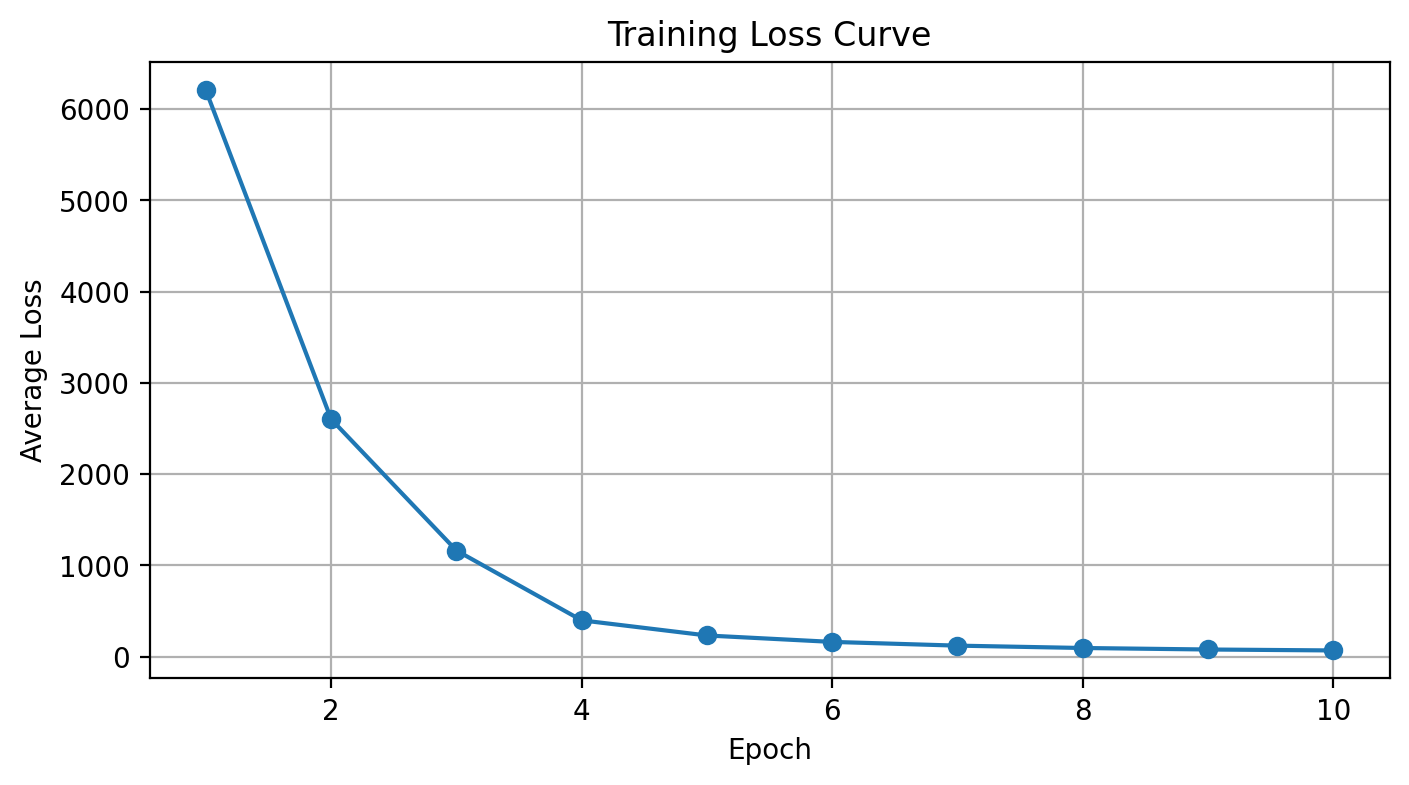

In [25]:
# 학습 곡선 확인 — loss가 꾸준히 감소하면 정상적으로 학습되고 있는 것입니다.
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

## 최종 결과 제출
---
학습이 끝난 모델로 예문을 번역하고, **Attention Map을 시각화**하여 번역 결과를 뒷받침합니다.

Translations

> 예문 1
Input: 오바마는 대통령이다.
Predicted translation: the local , the local the local , the local , the local , the local , the local , the local , the local , the local , the year , the local , the local , the local , the local the third was been hospitalized to
Encoder Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

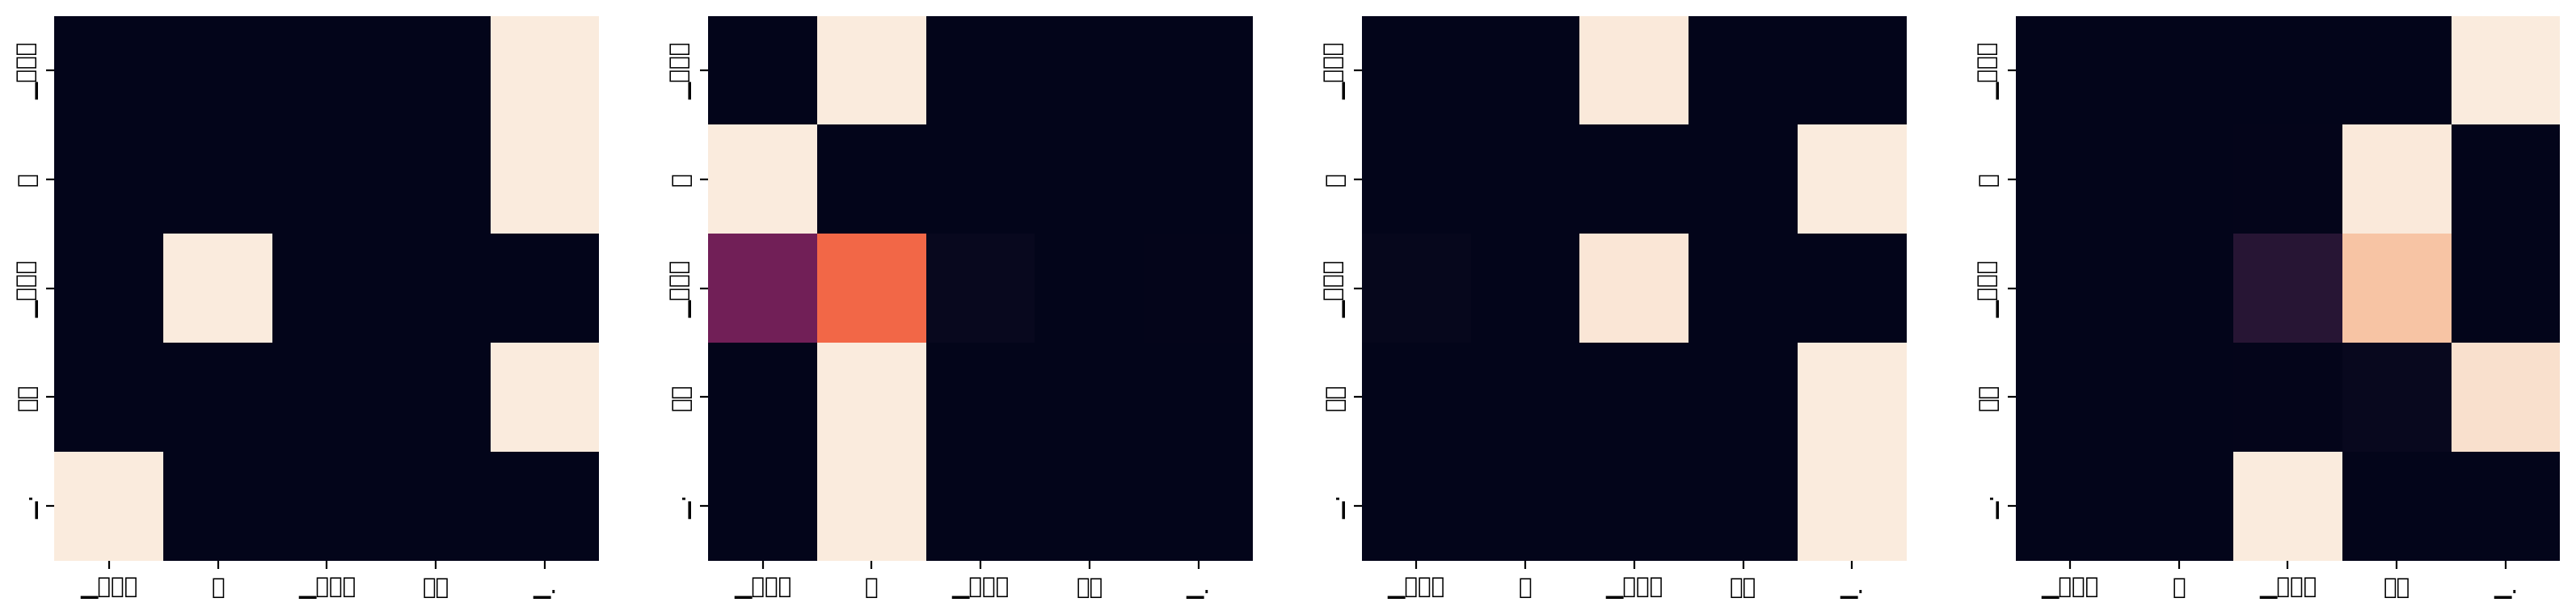

Encoder Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

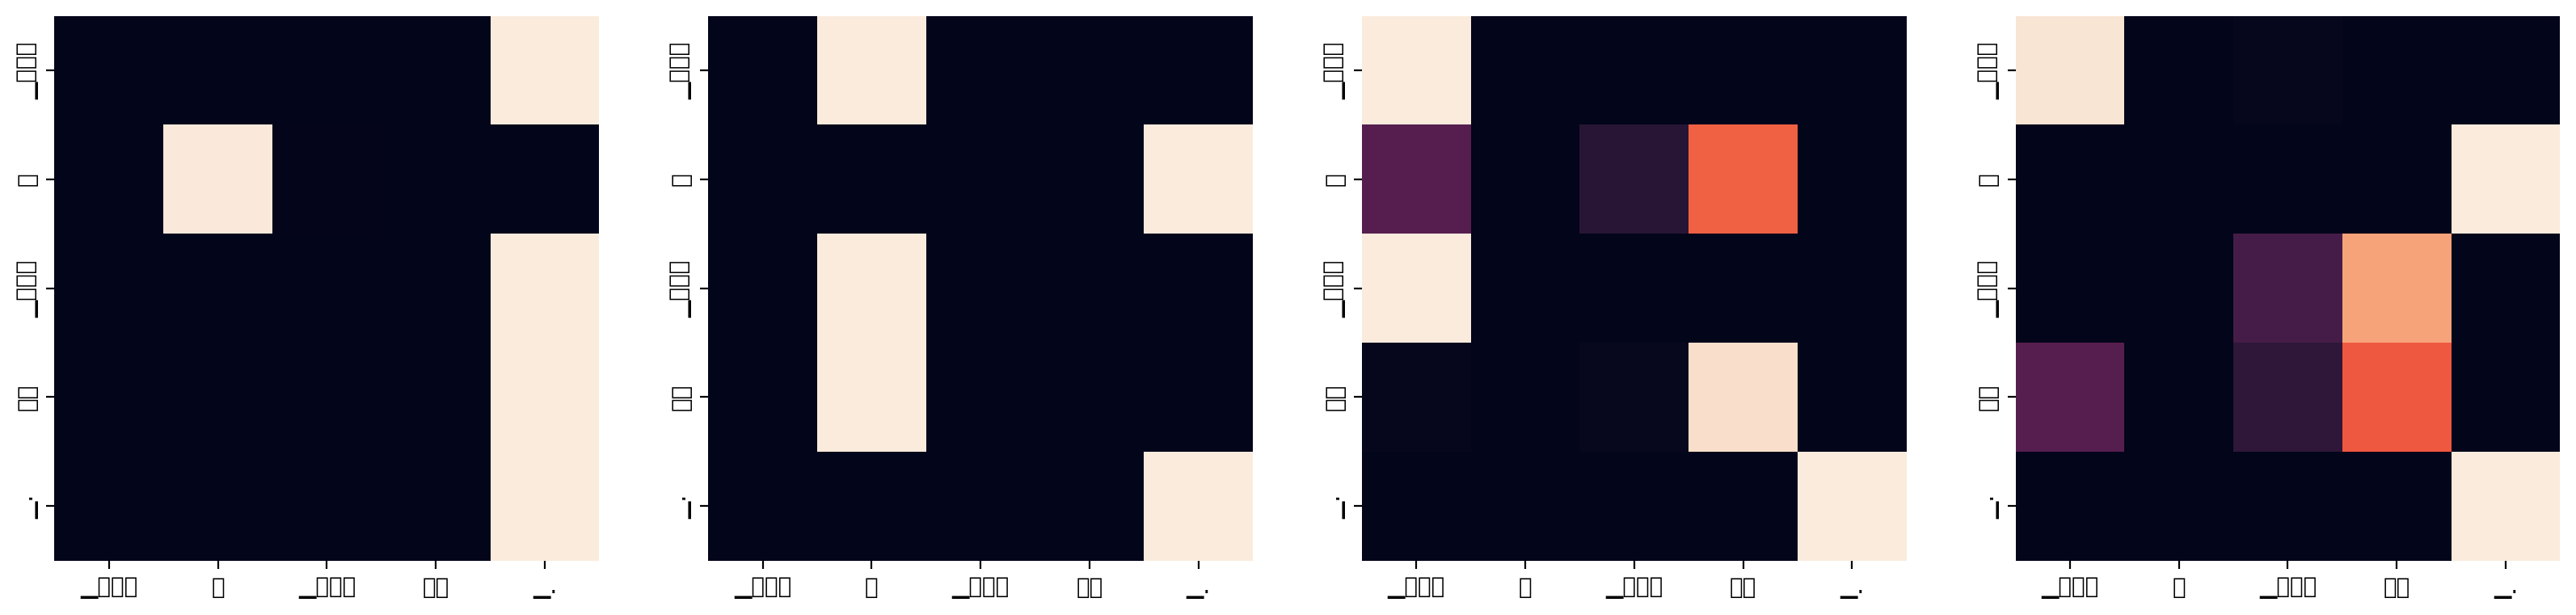

Decoder Self Layer 1


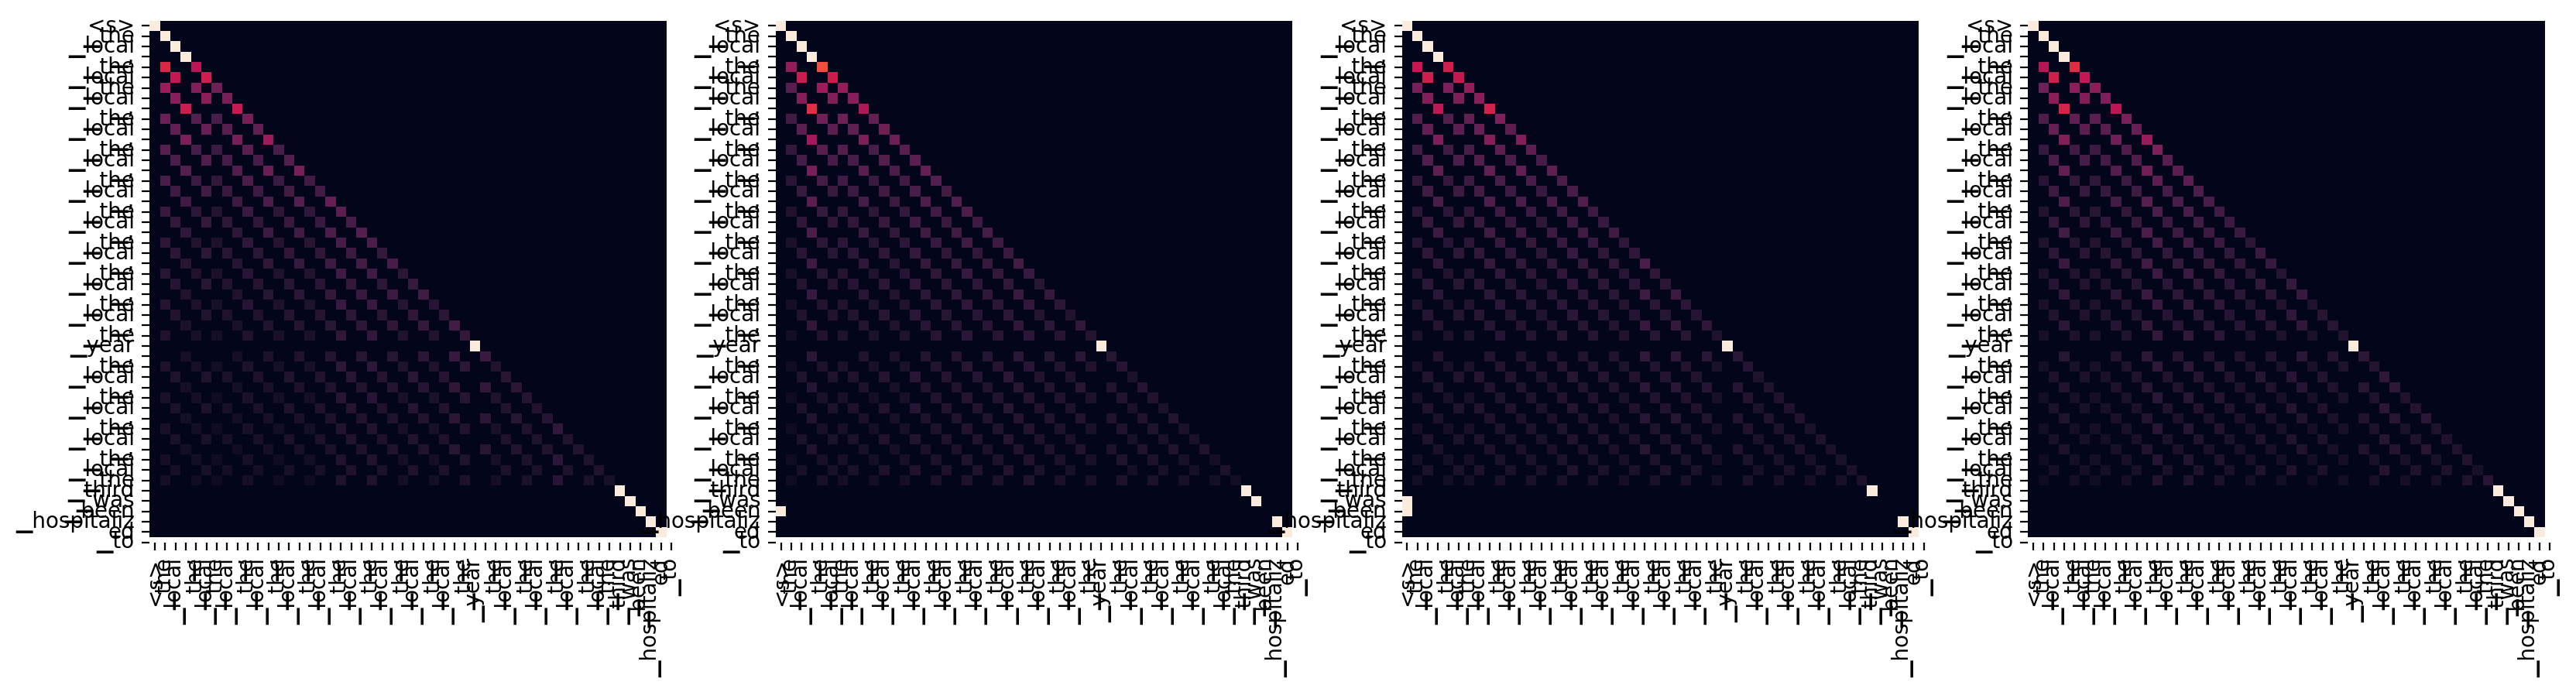

Decoder Src Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

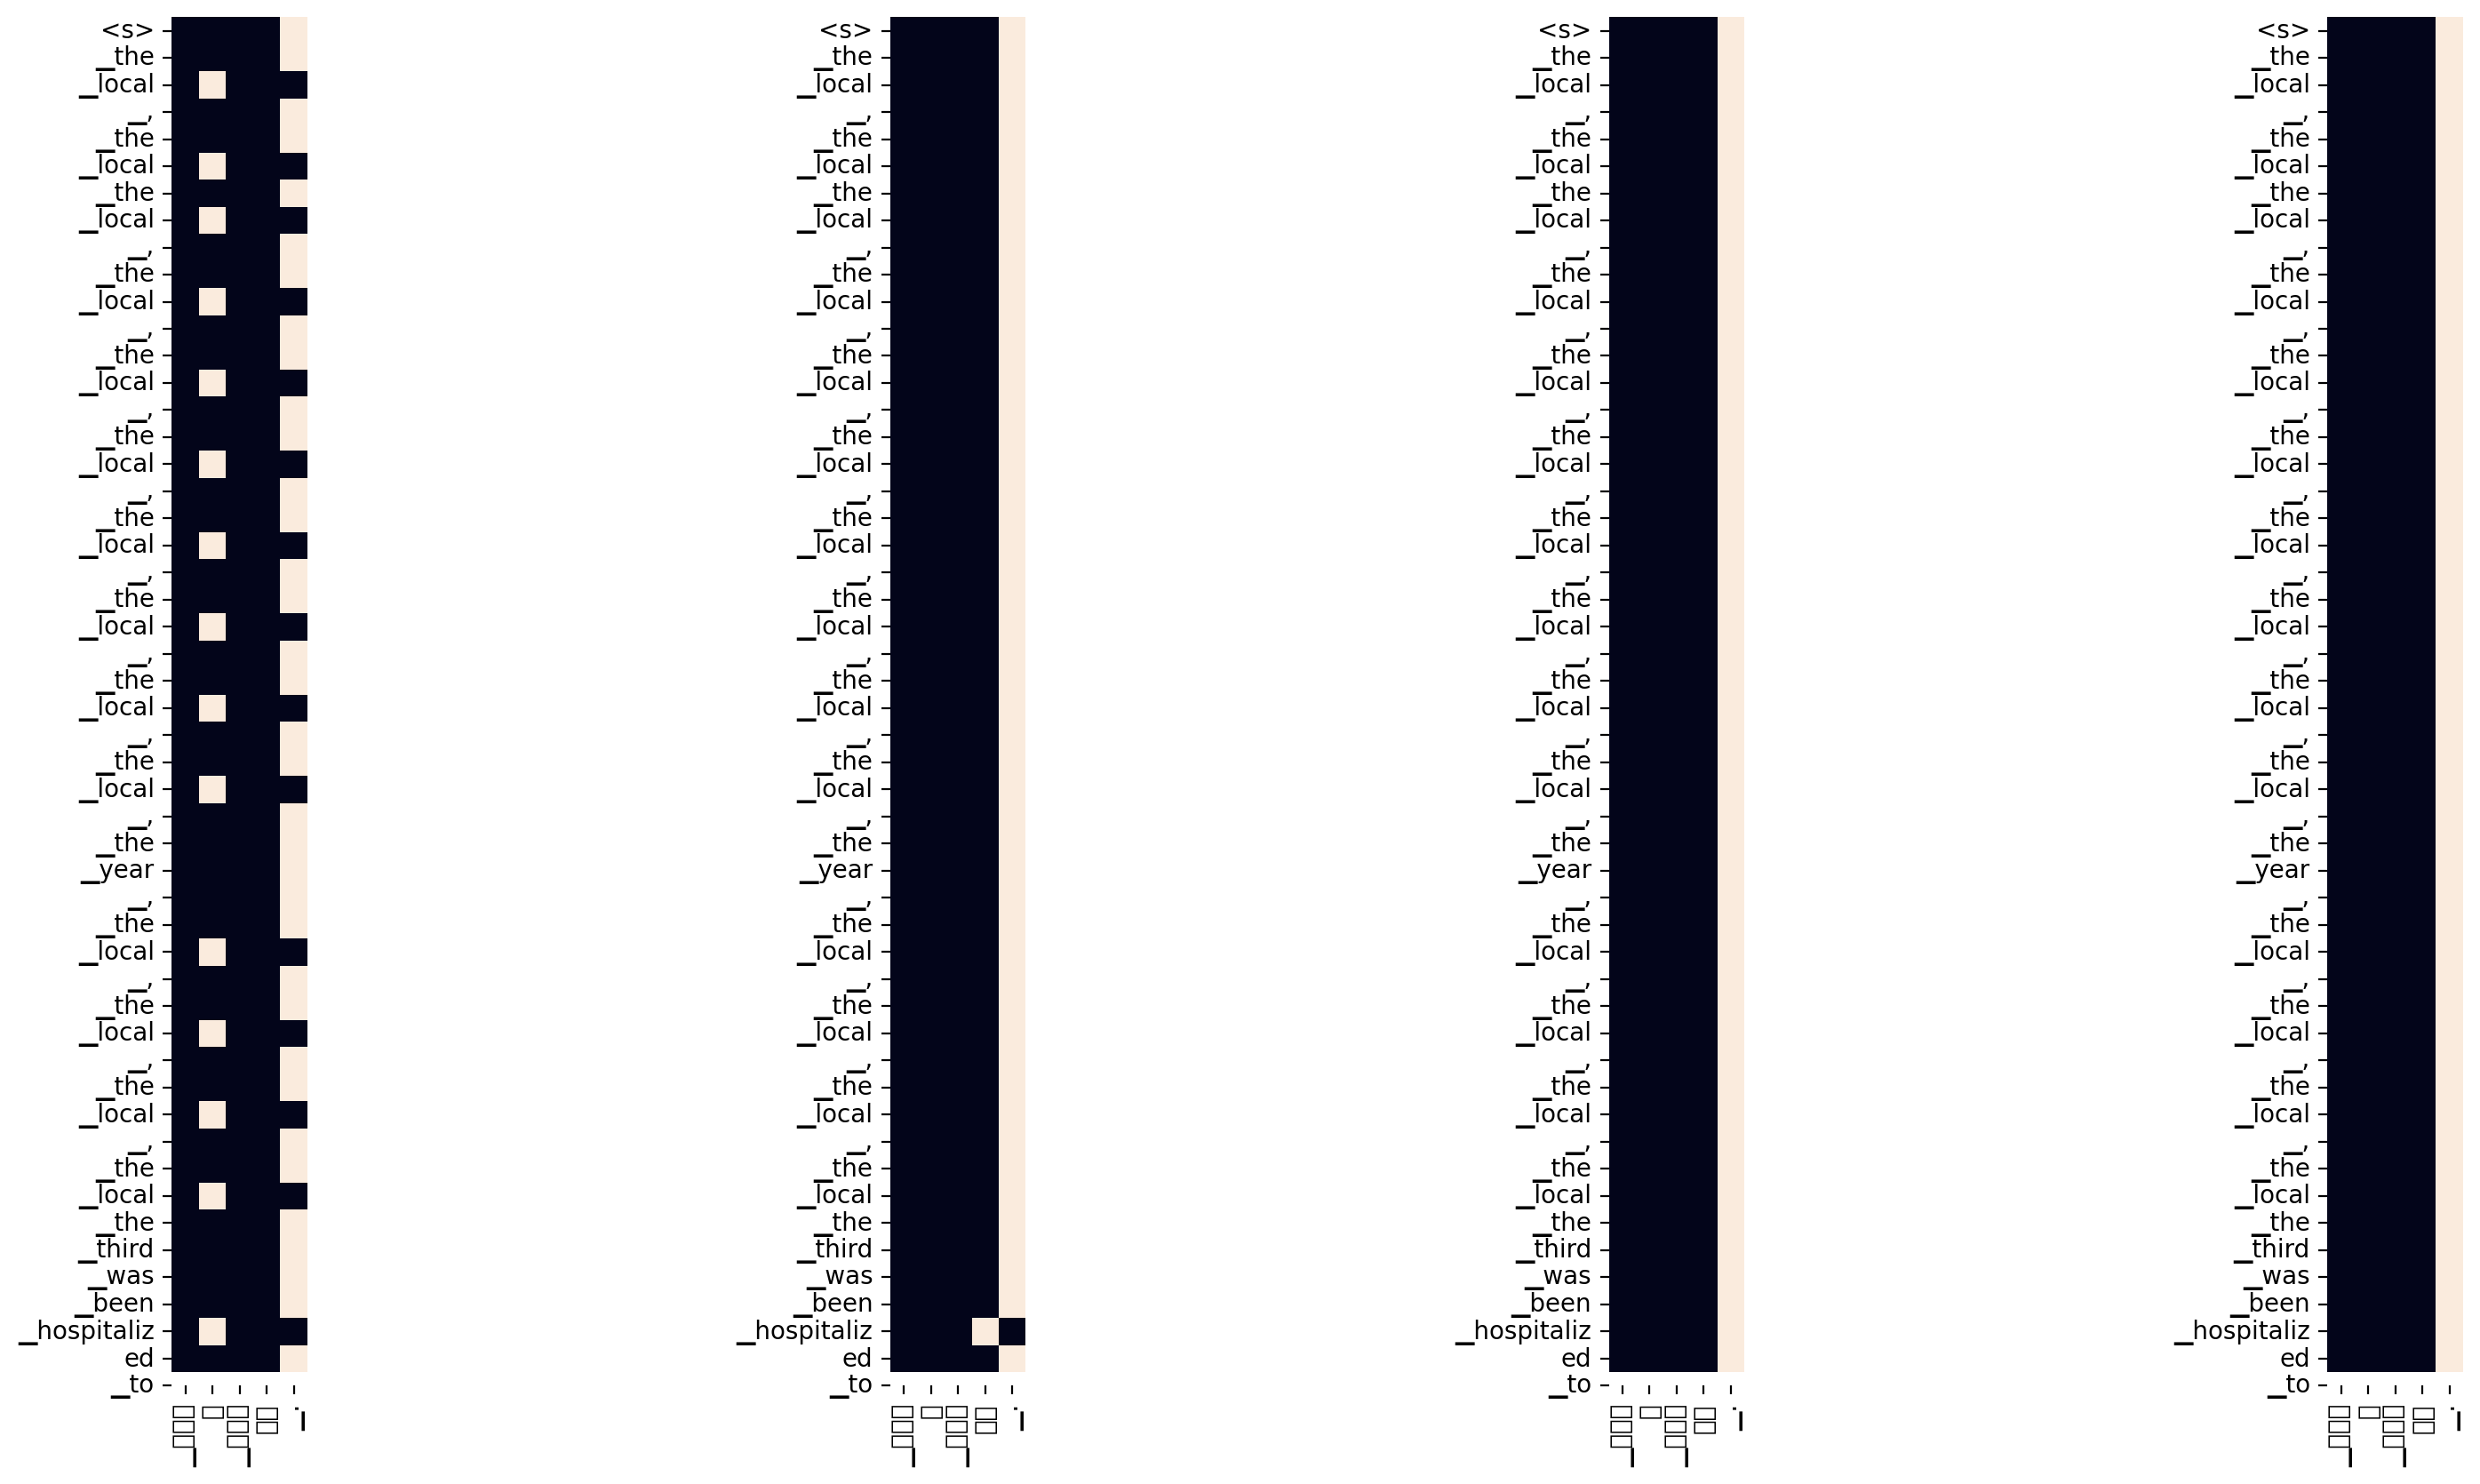

Decoder Self Layer 2


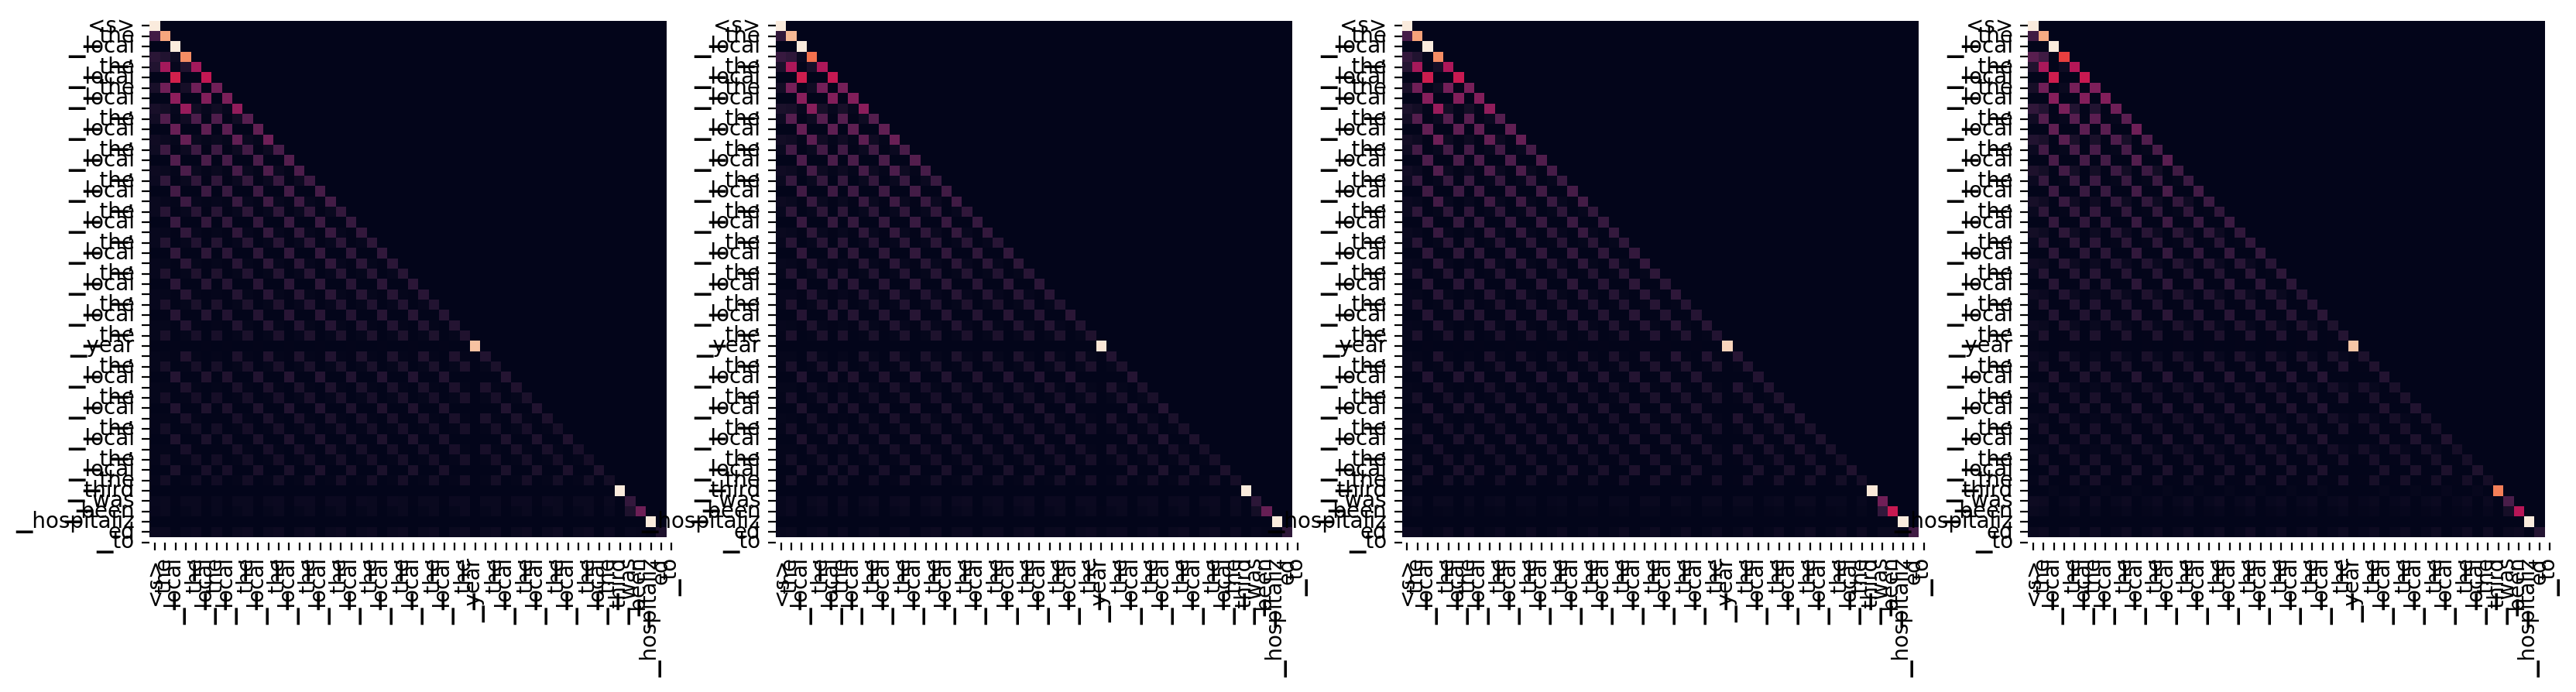

Decoder Src Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

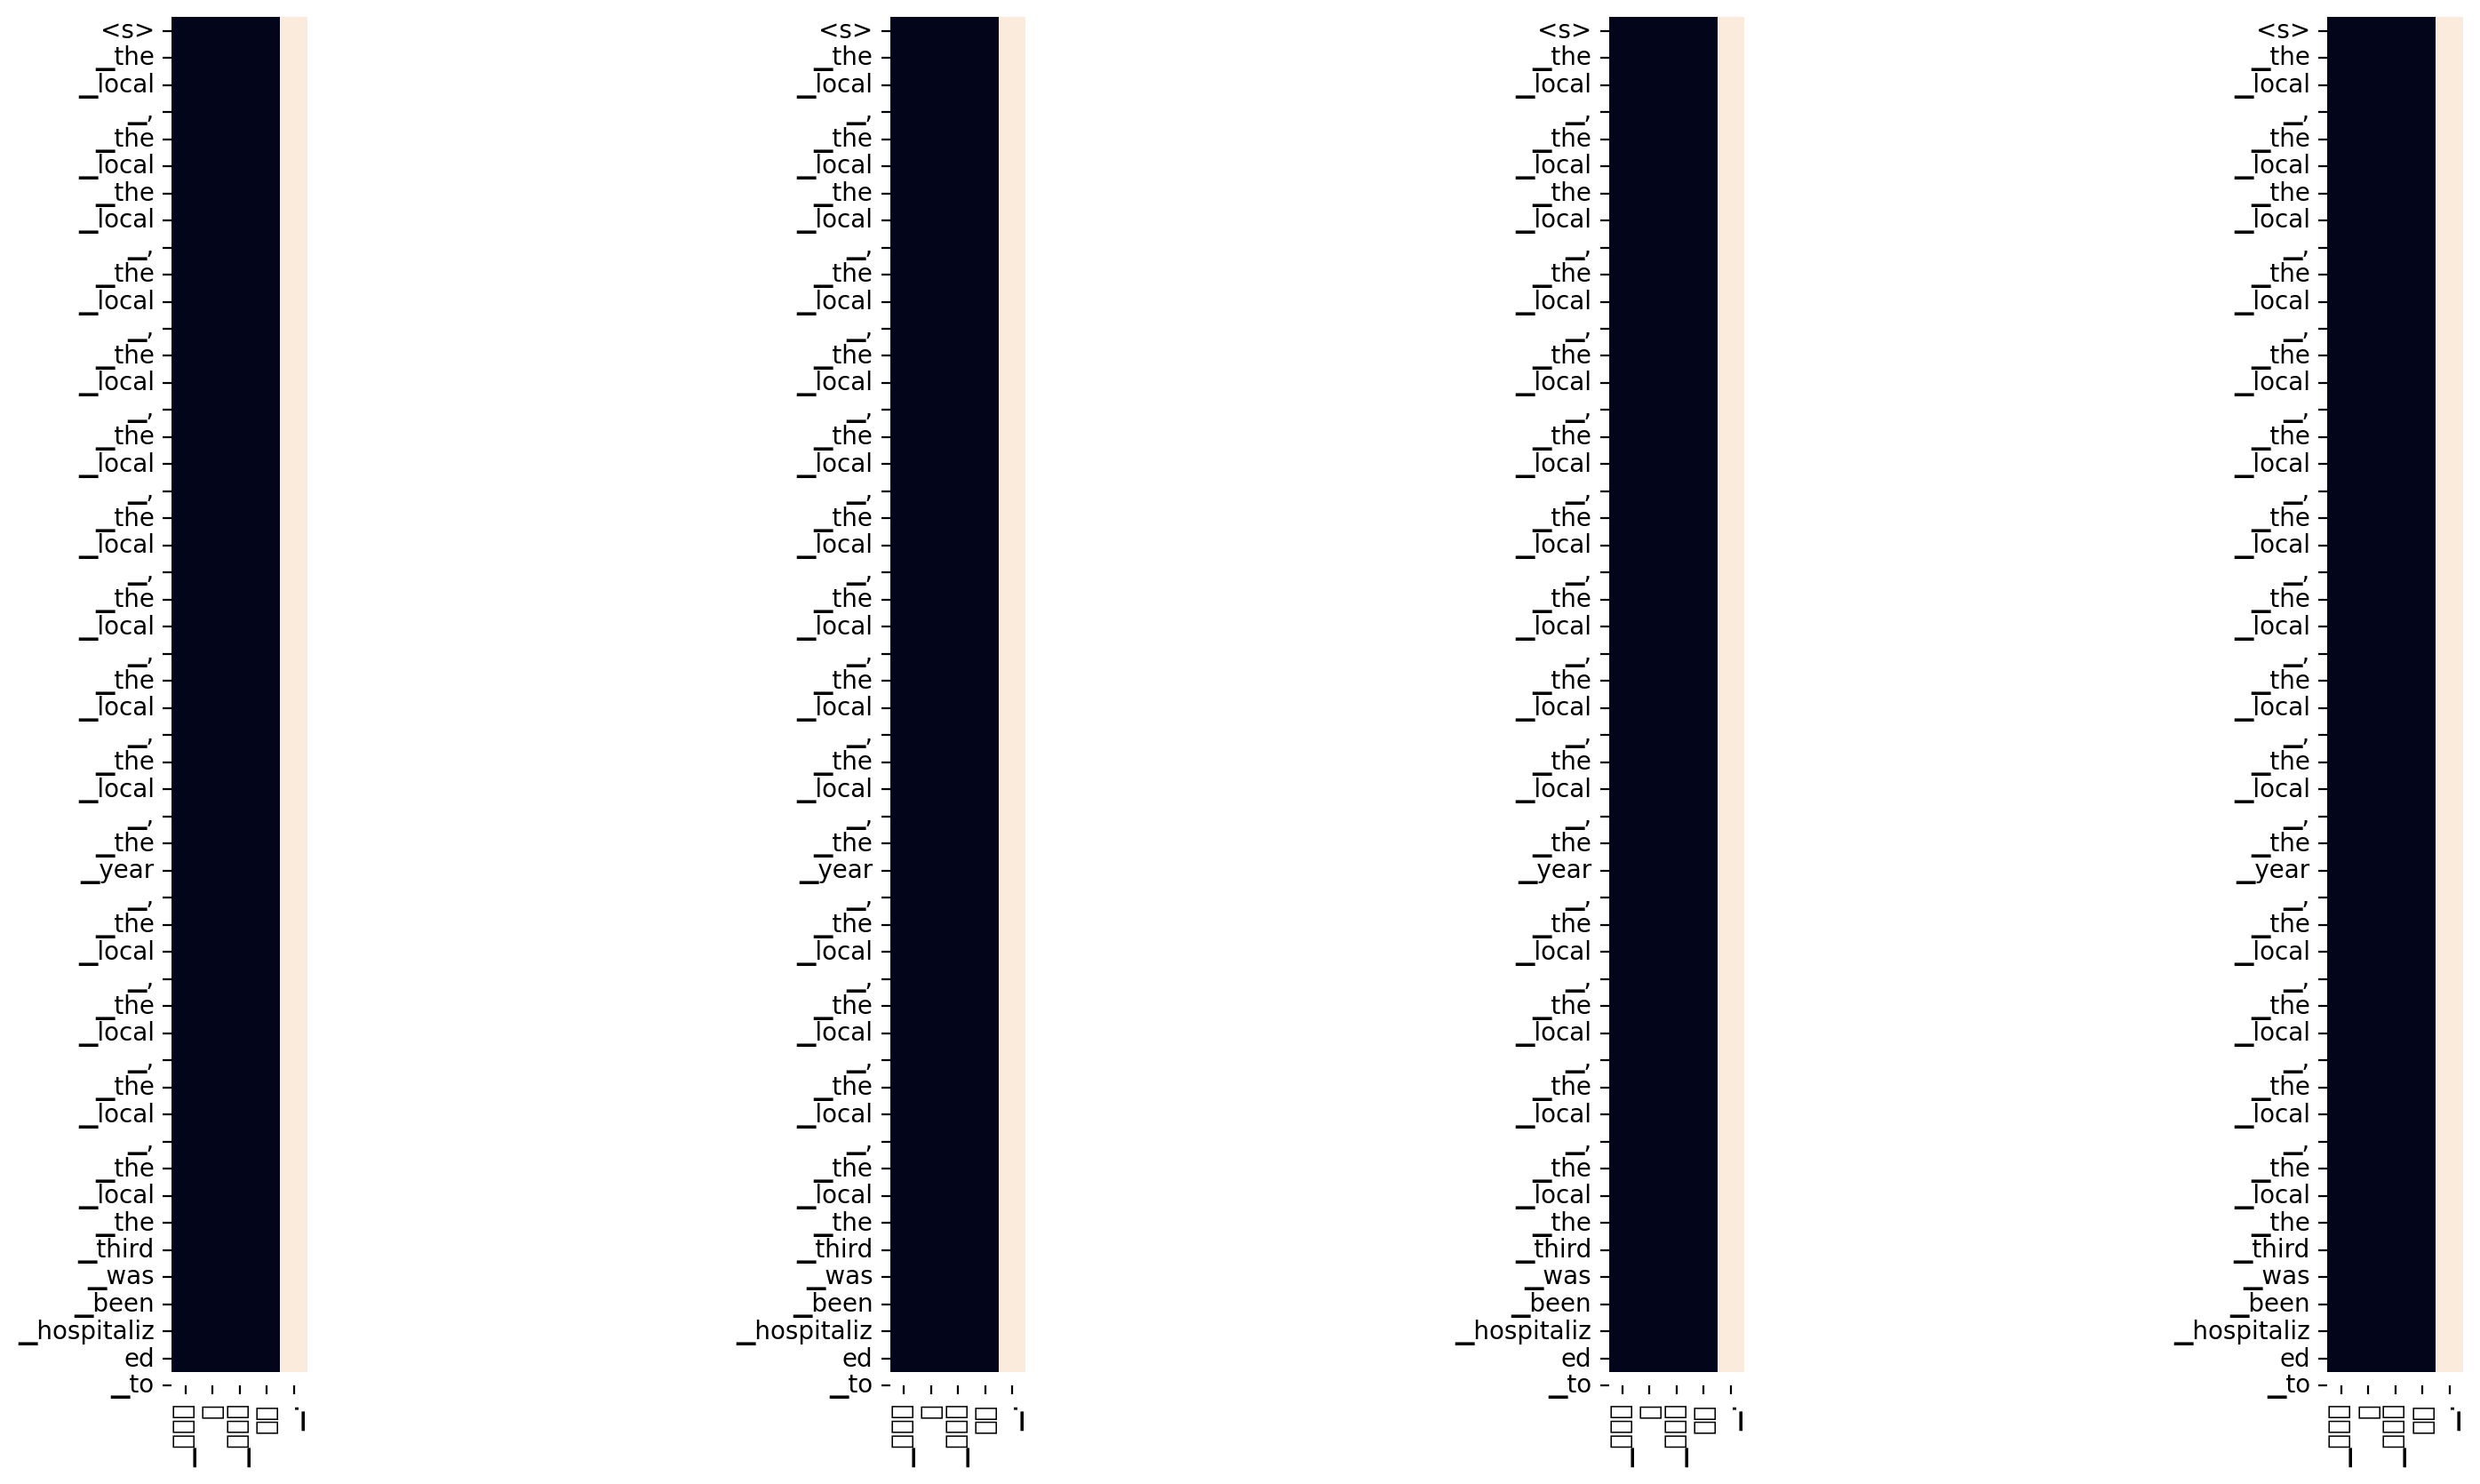


> 예문 2
Input: 시민들은 도시 속에 산다.
Predicted translation: the second more than another the second more than the second more than another the second more than another the second more than another the local the second more than the second more than the second more than another the second more than the local
Encoder Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/

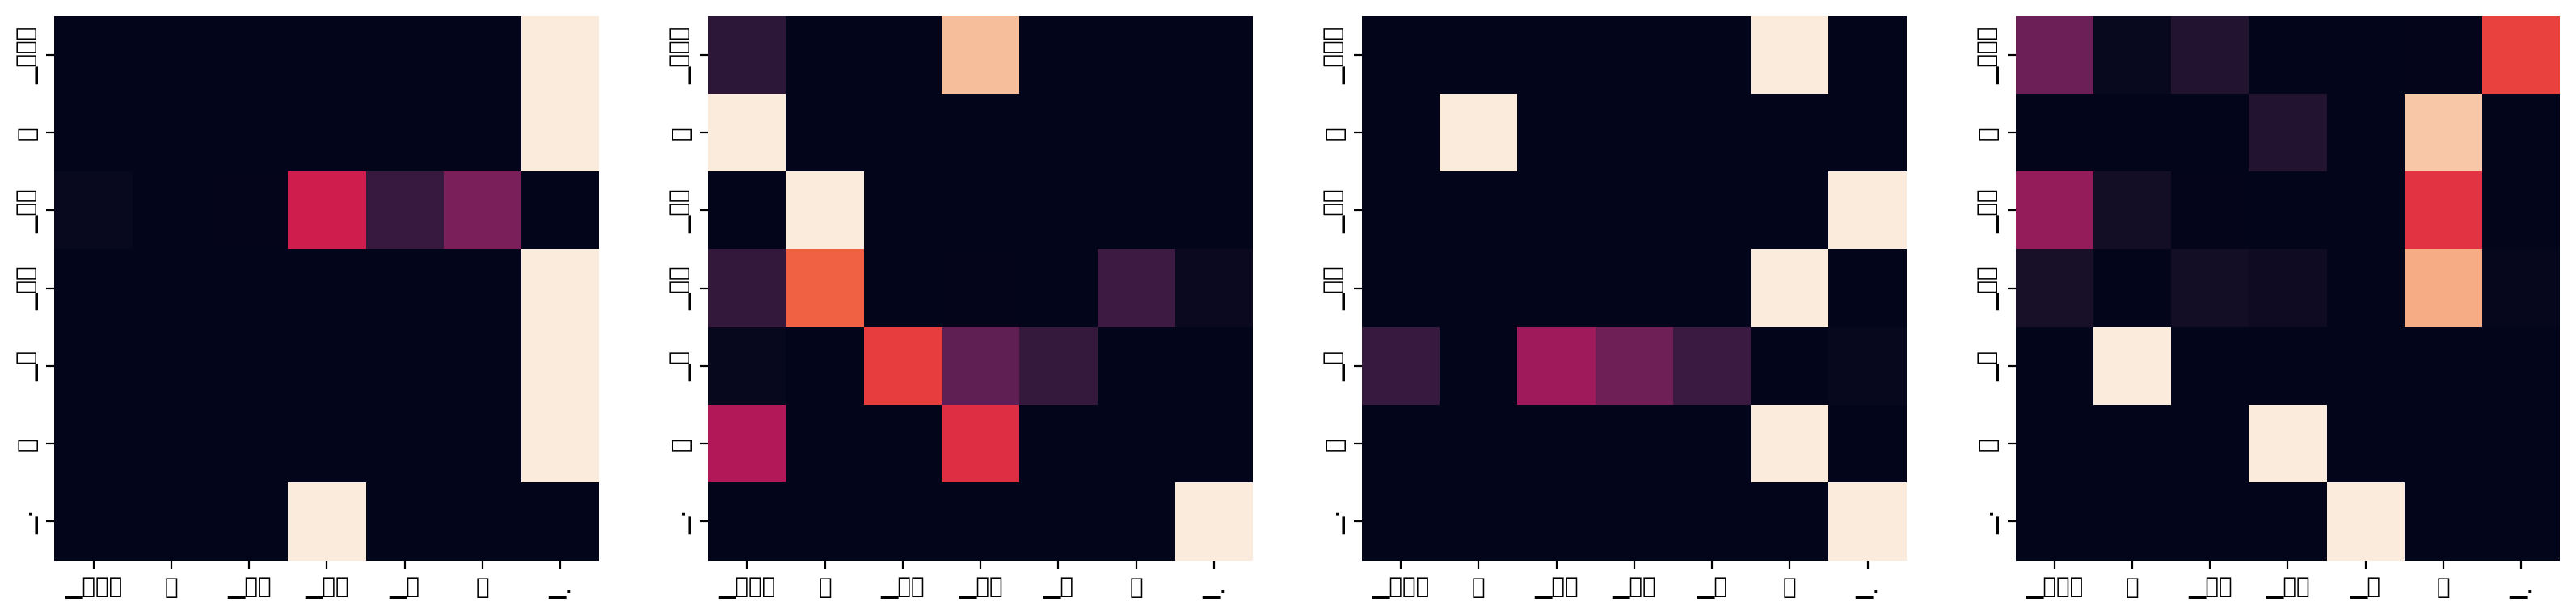

Encoder Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/

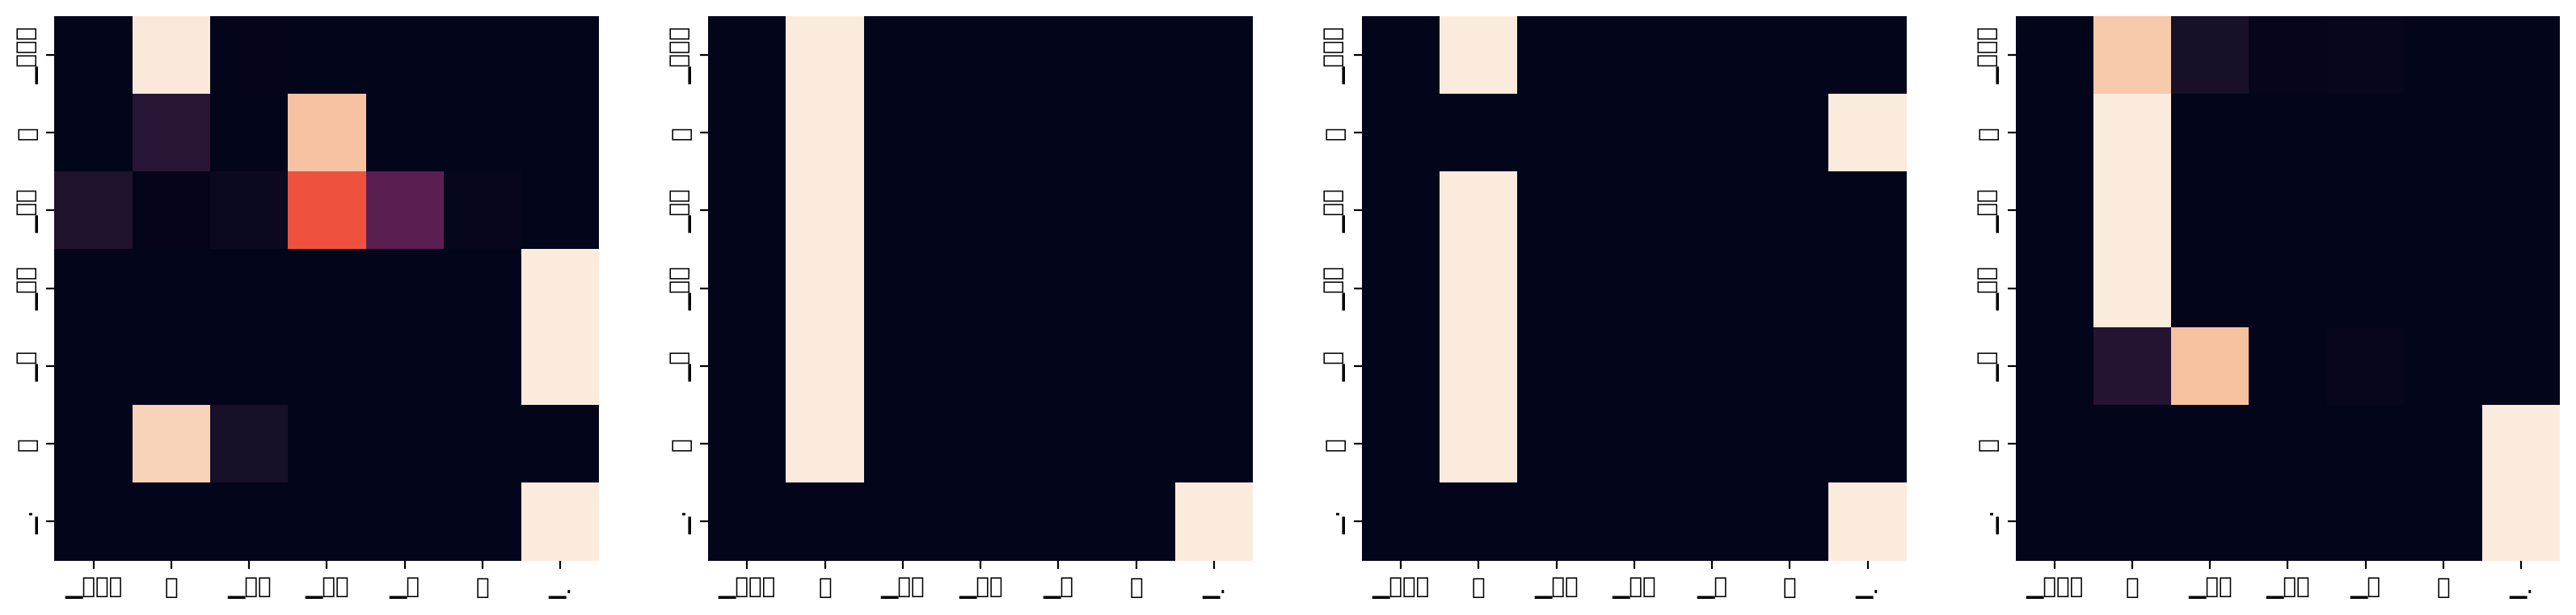

Decoder Self Layer 1


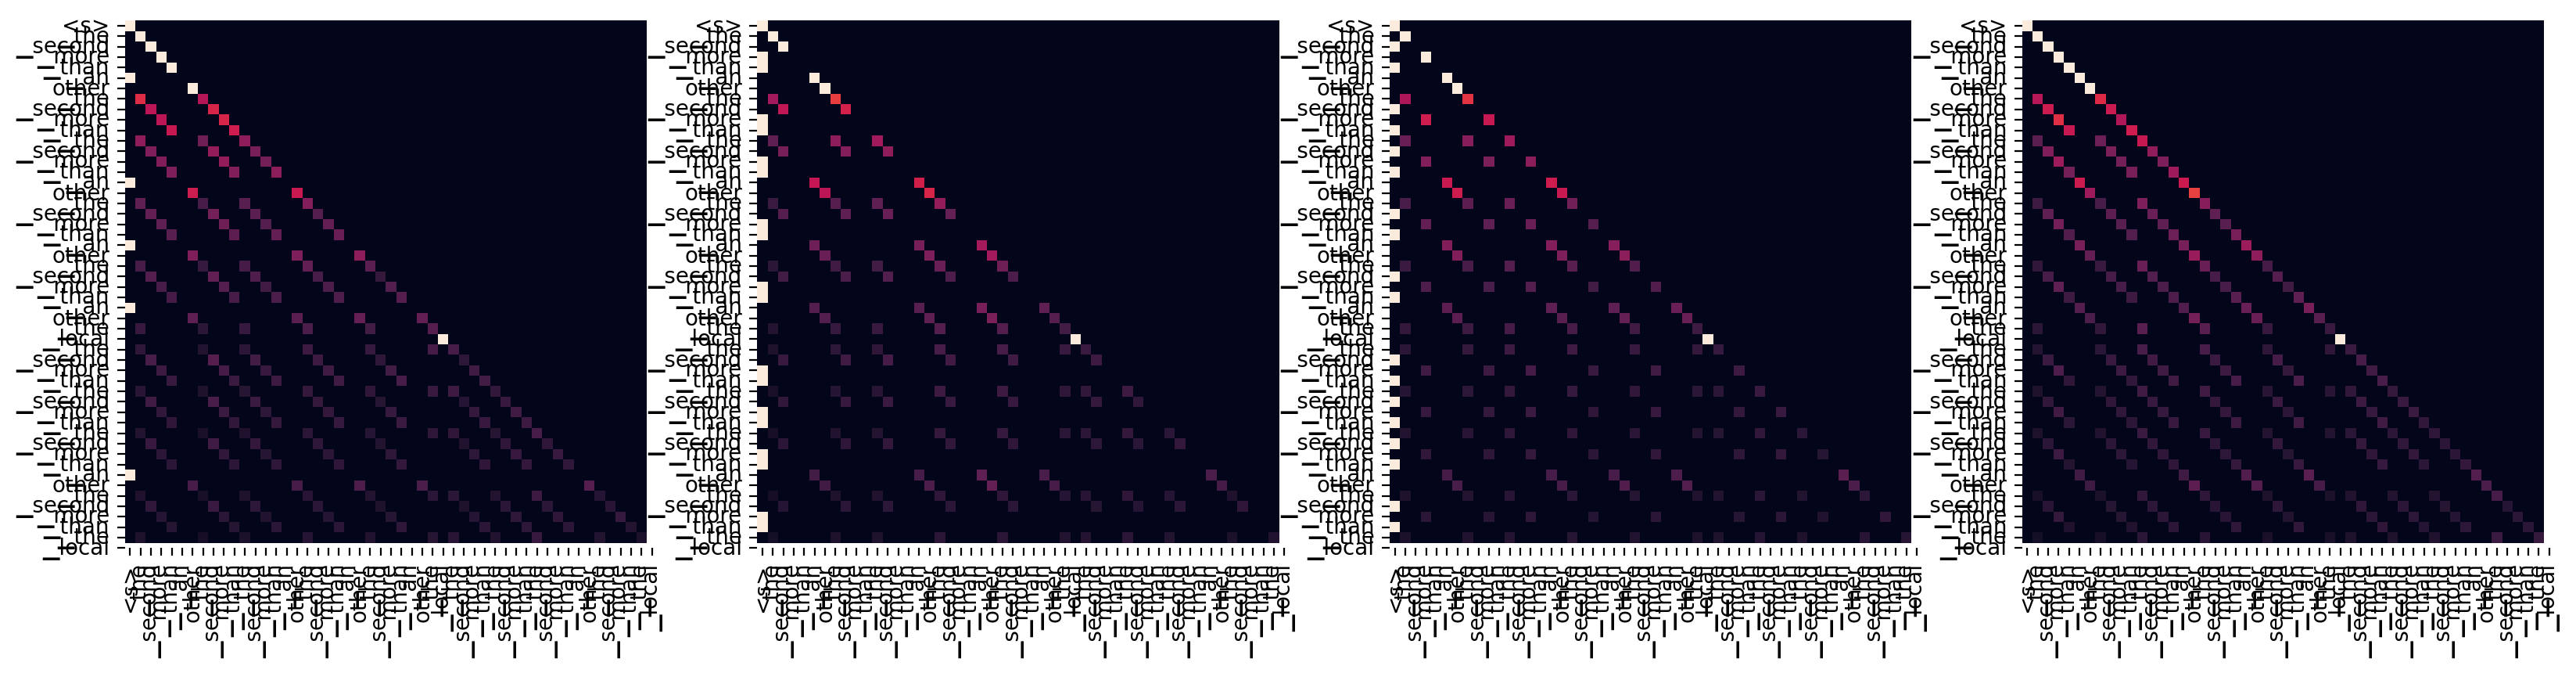

Decoder Src Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/

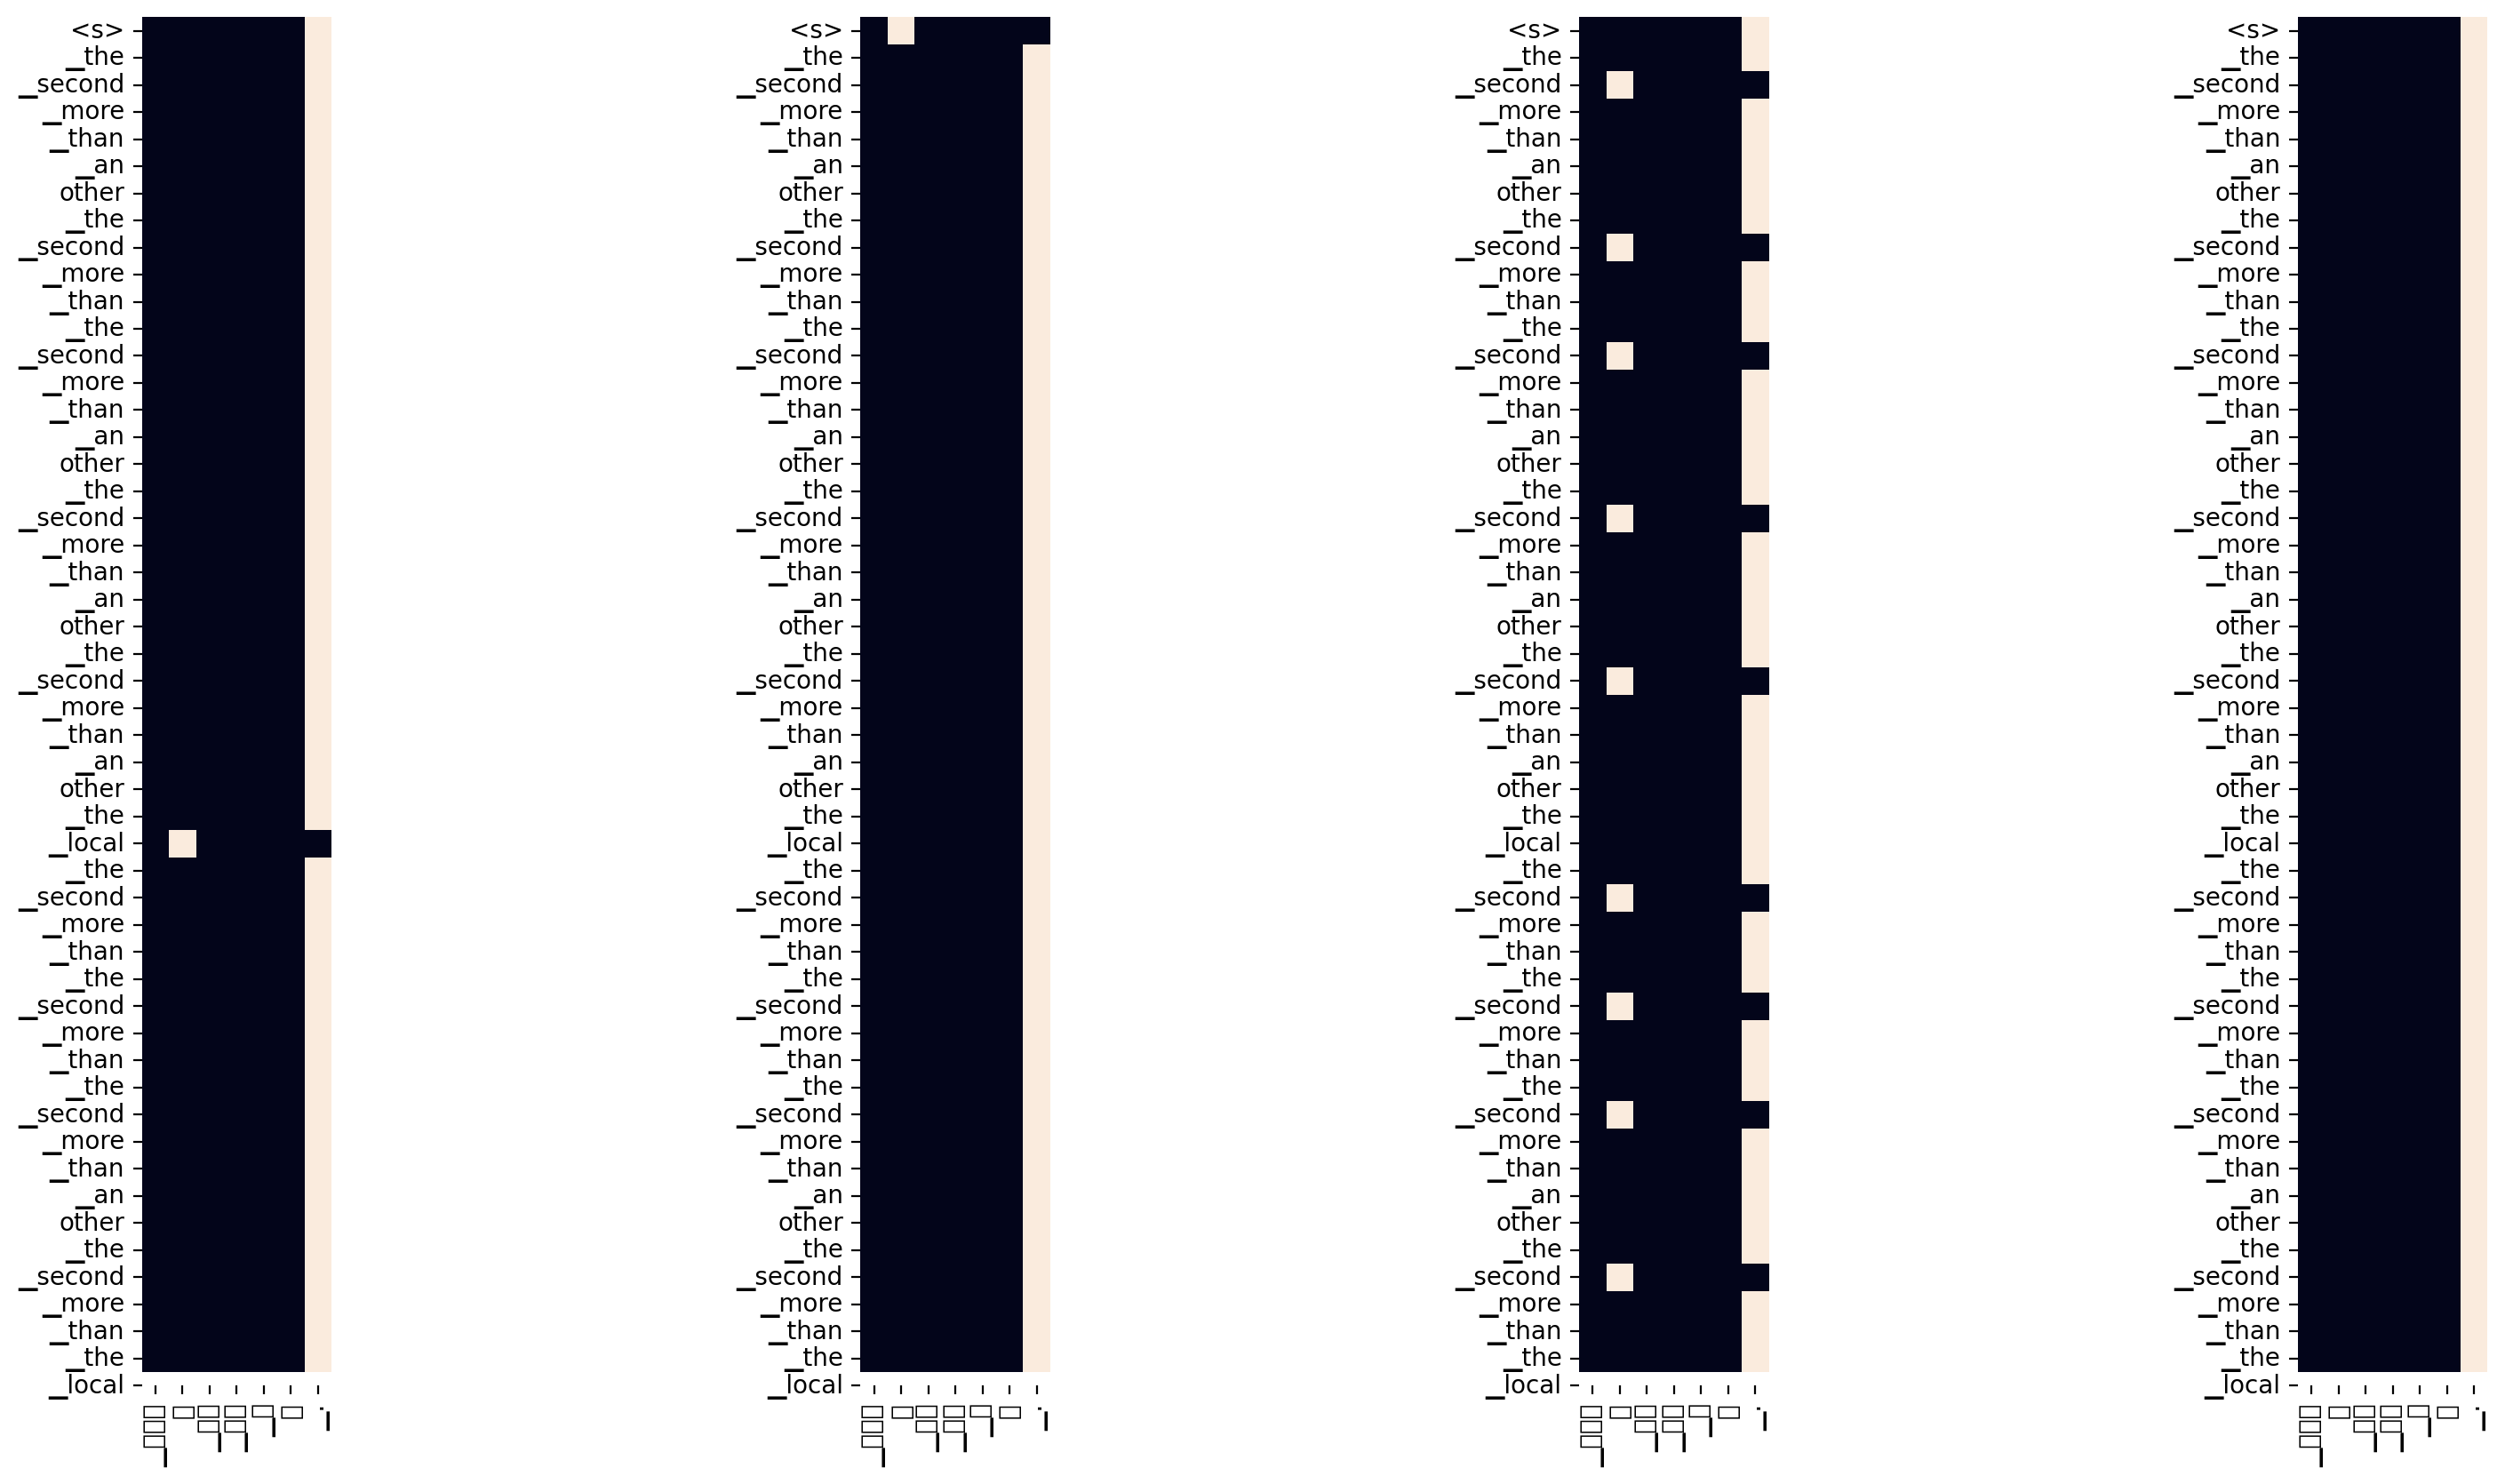

Decoder Self Layer 2


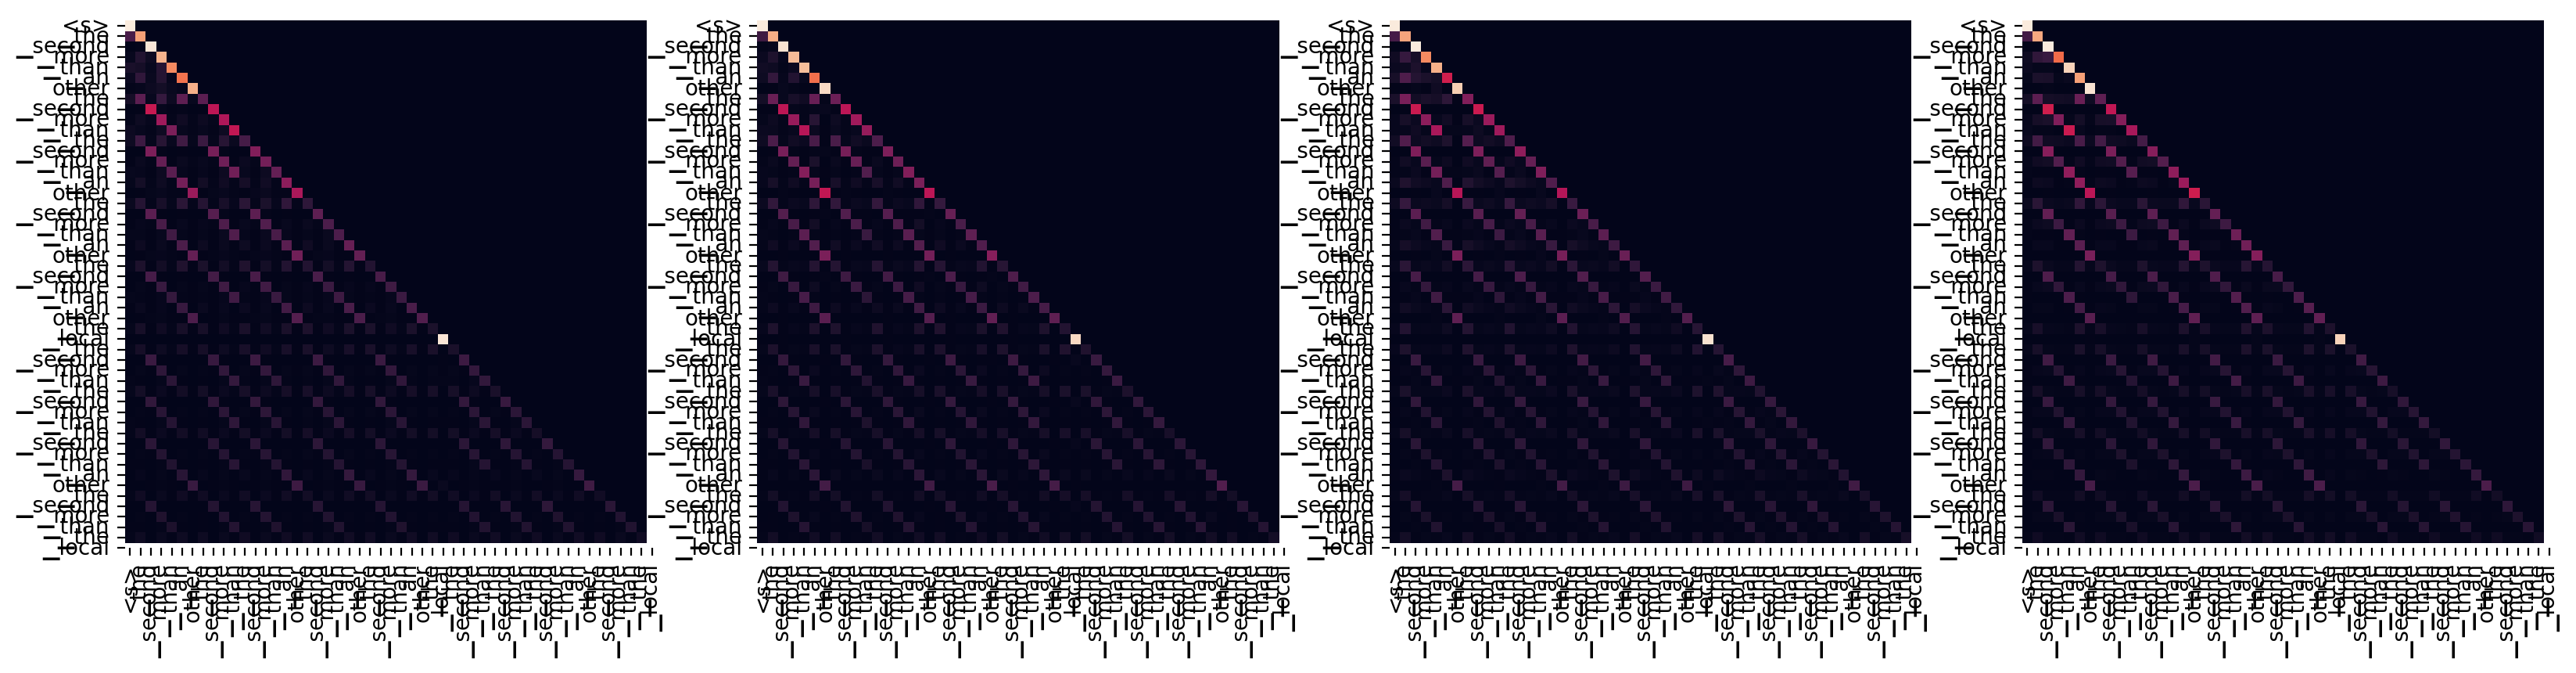

Decoder Src Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/

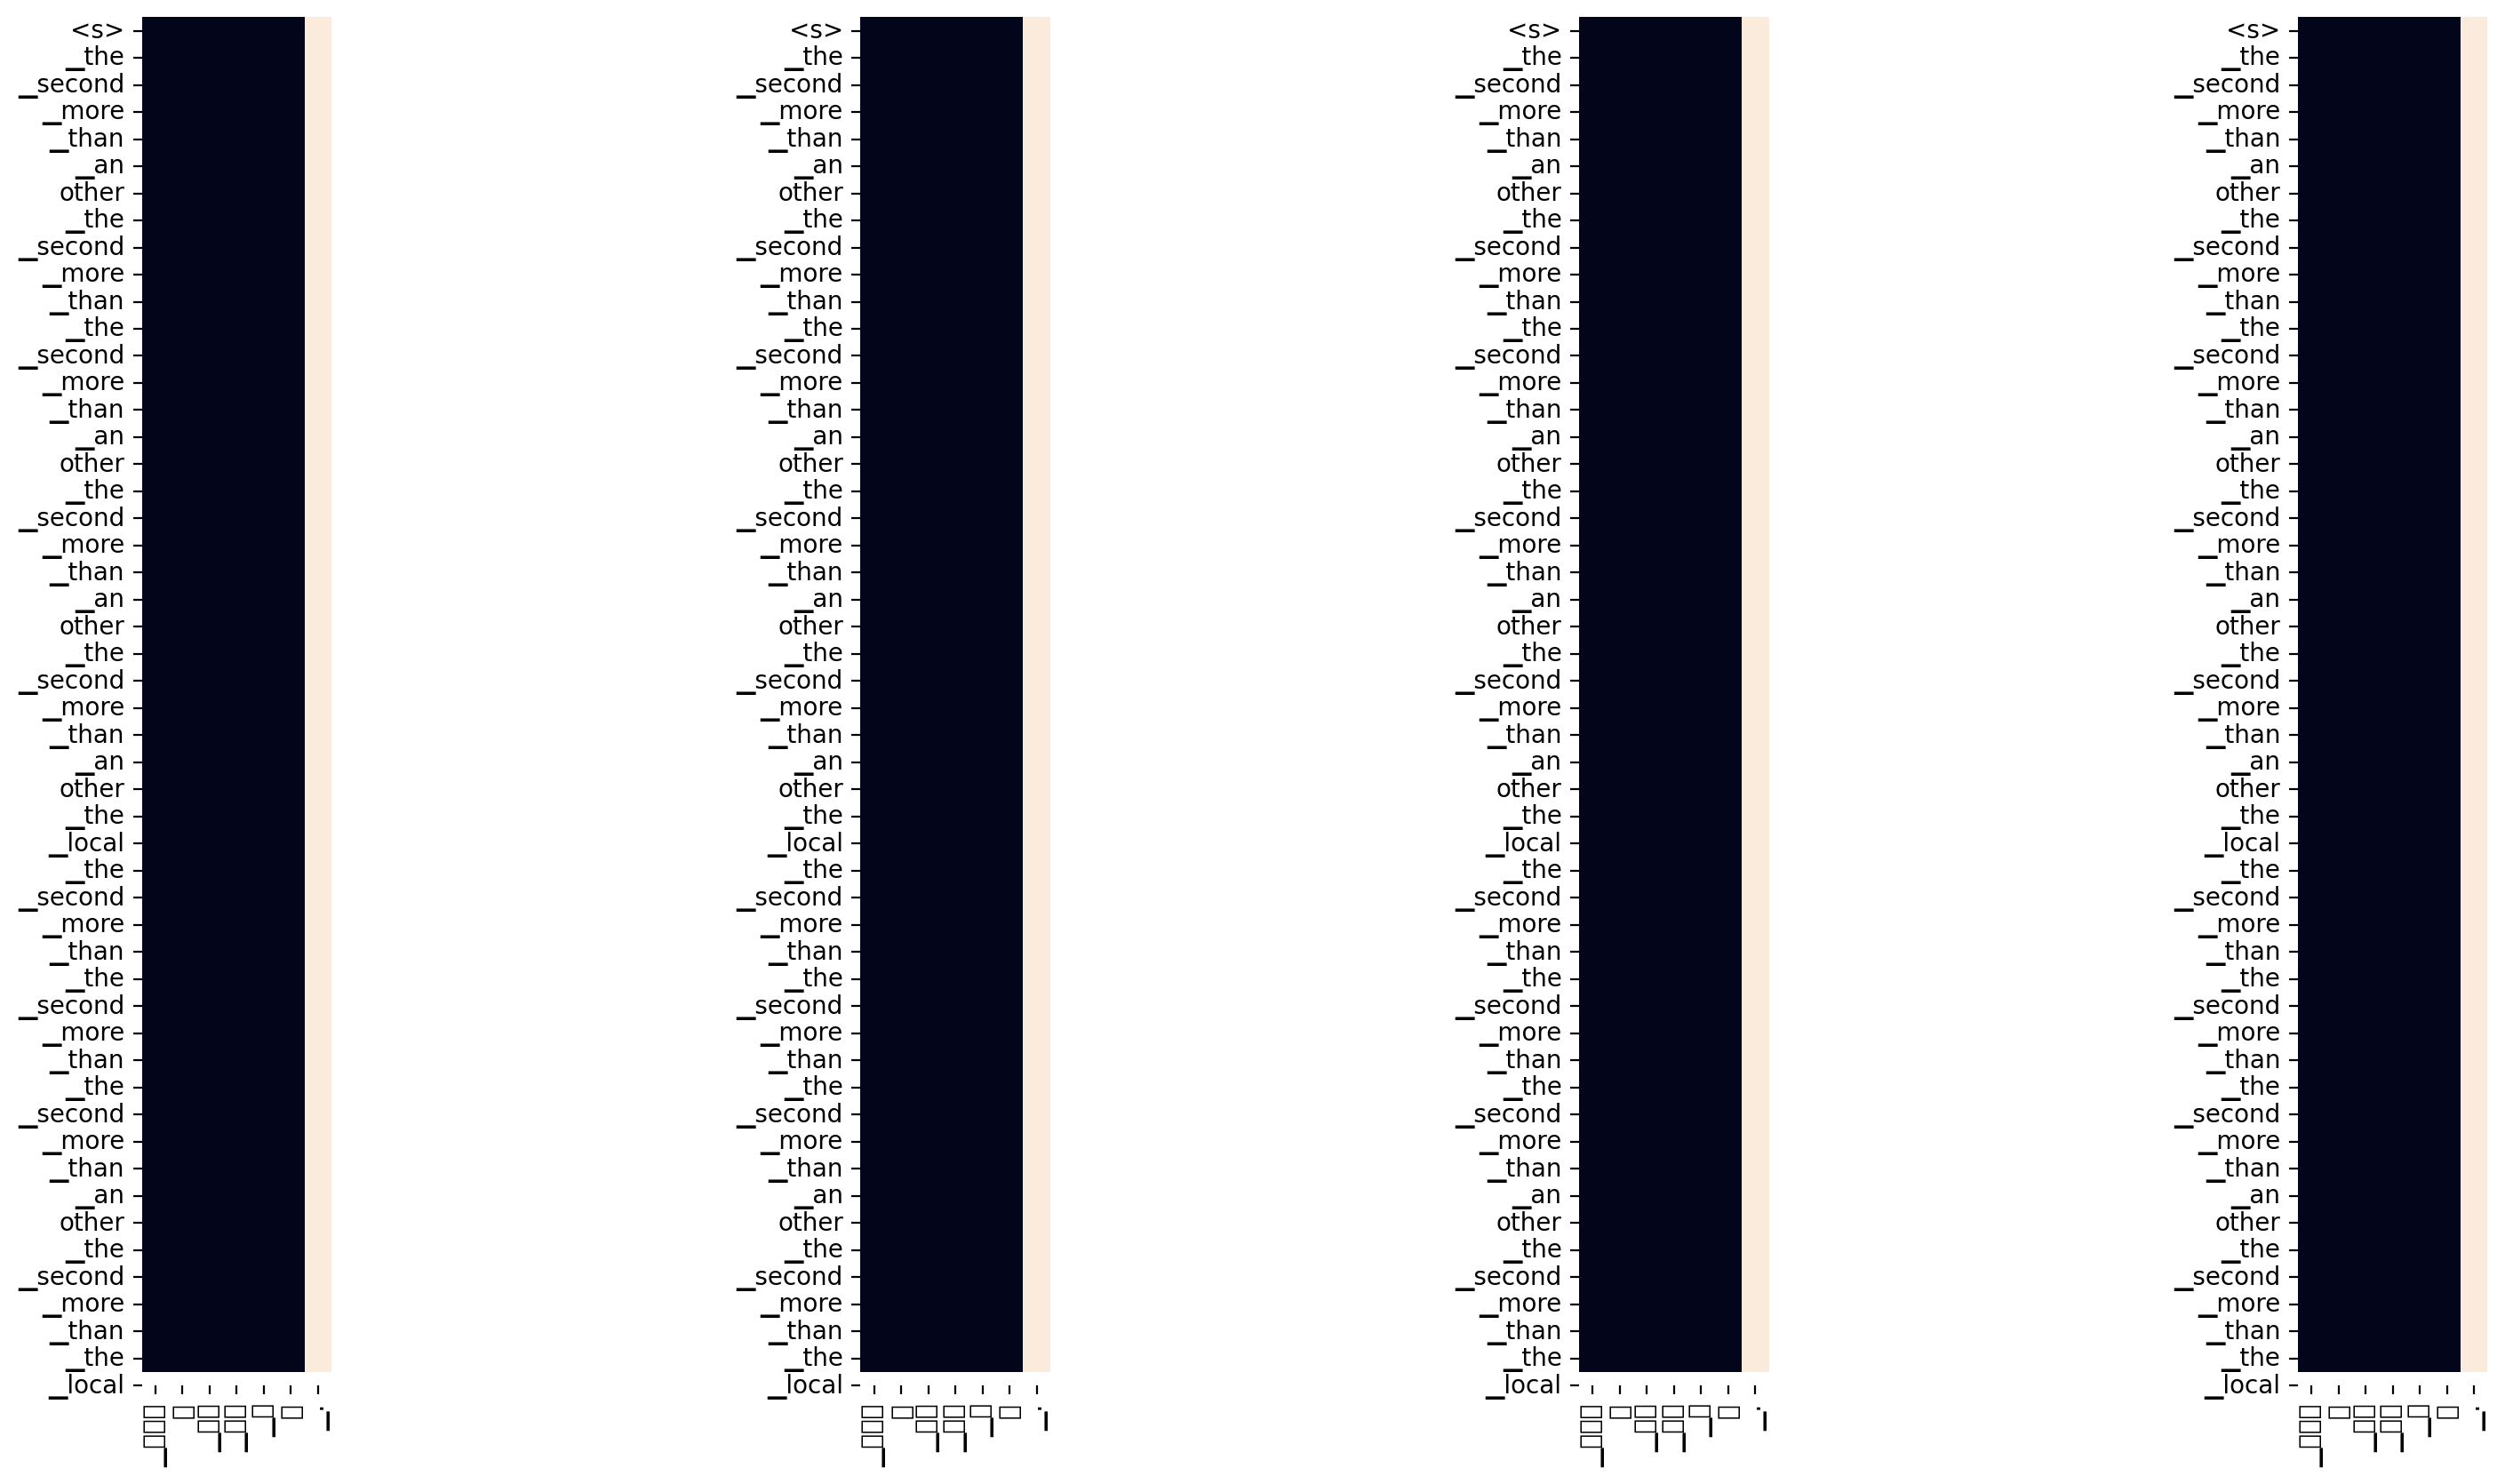


> 예문 3
Input: 커피는 필요 없다.
Predicted translation: the year , the year , the year , the year , the year , the third is not been hospitalized the third is the local , the year , the international the year , the year , the year , the third is the year , the internet
Encoder Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

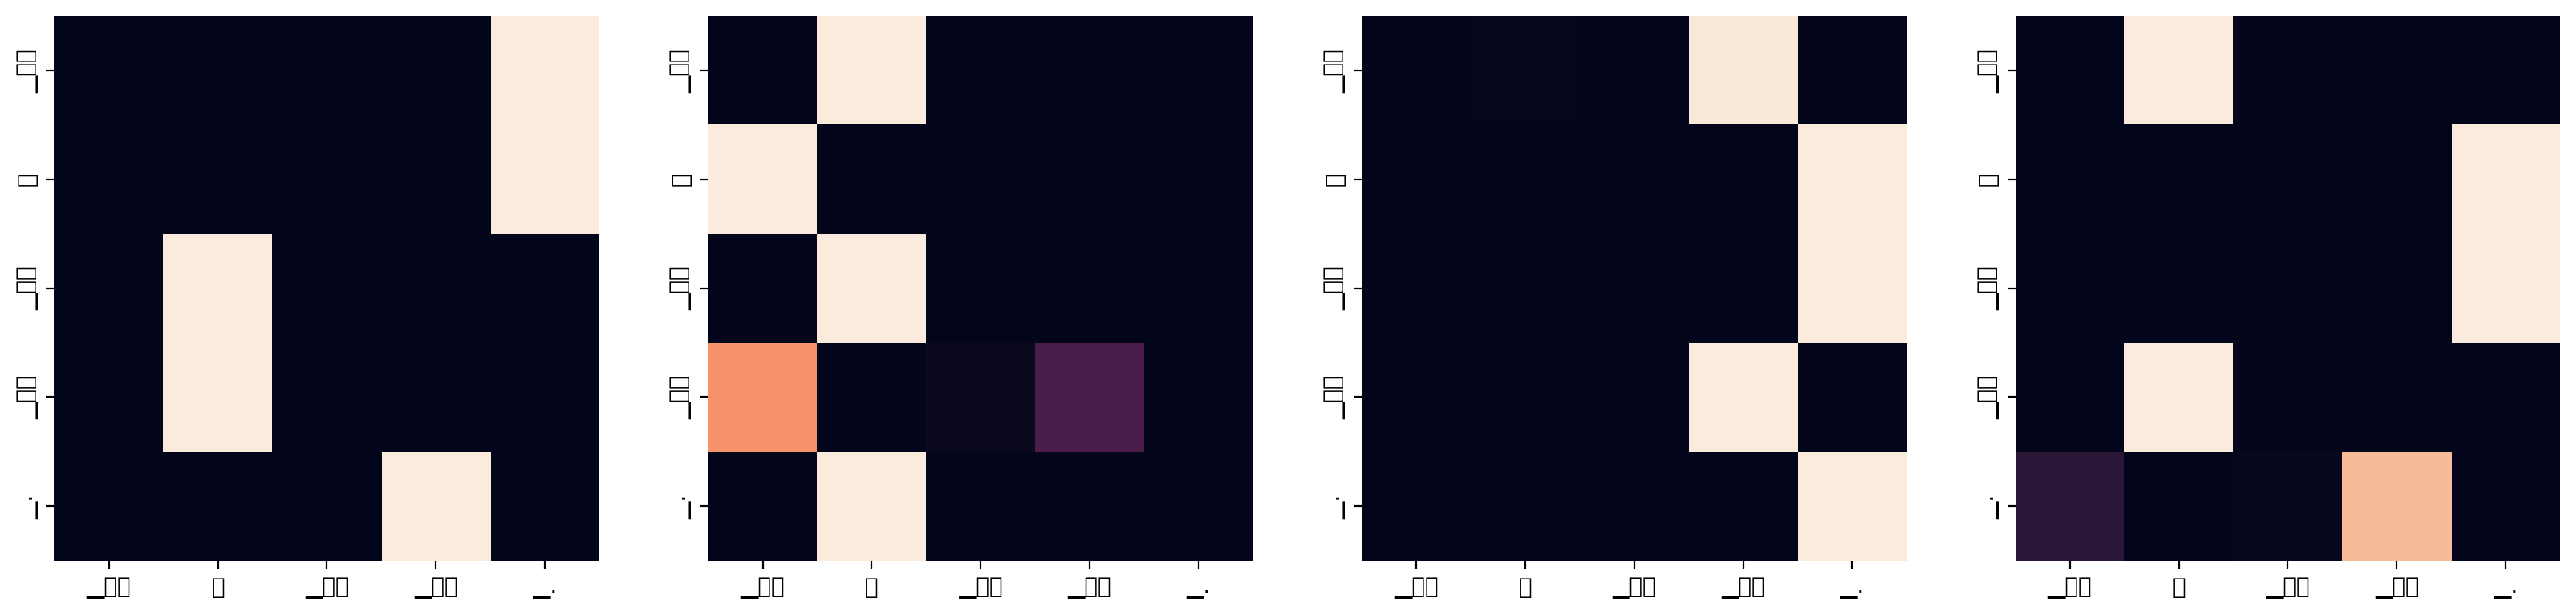

Encoder Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

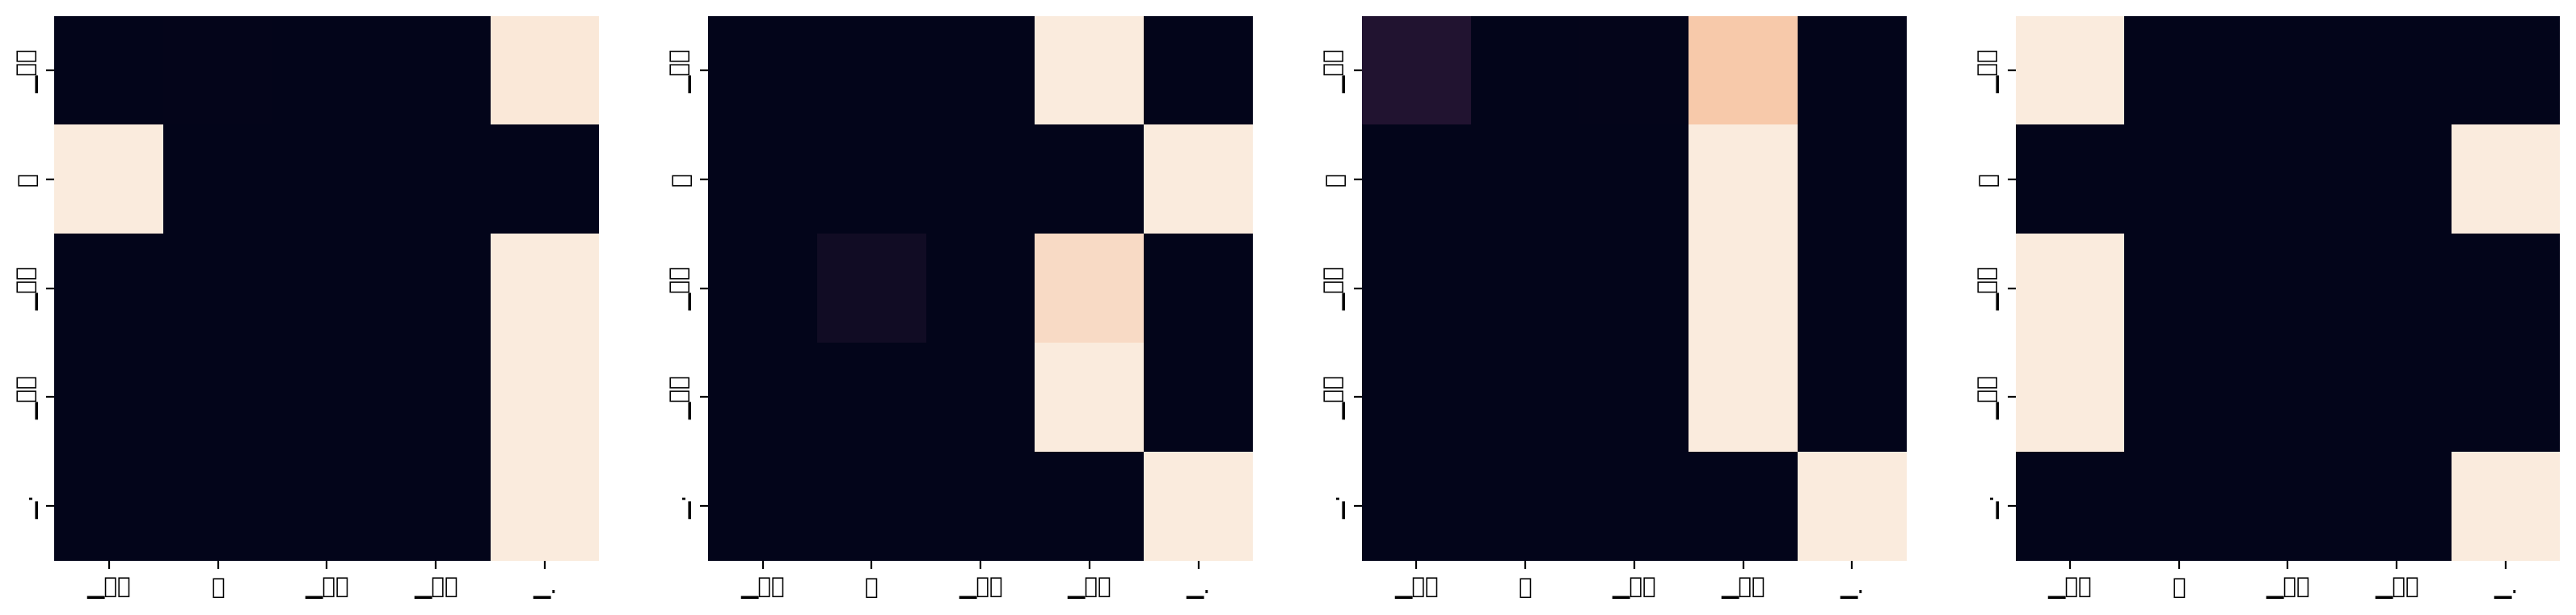

Decoder Self Layer 1


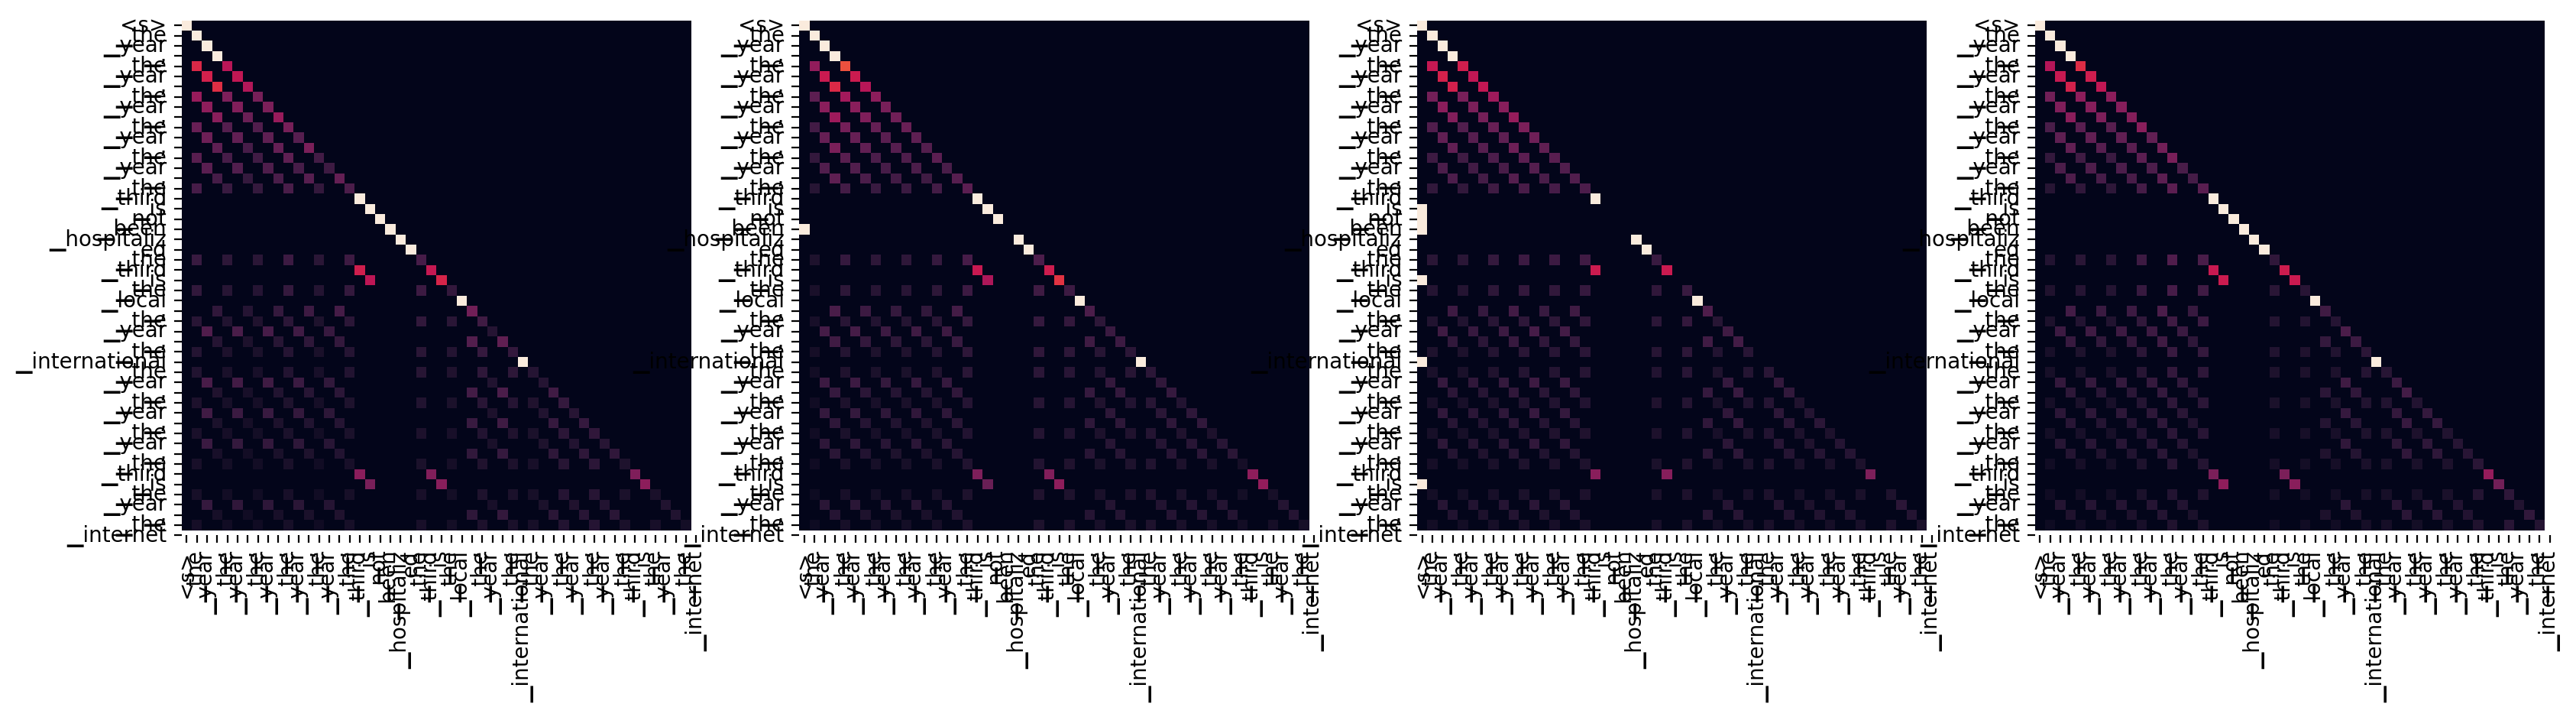

Decoder Src Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

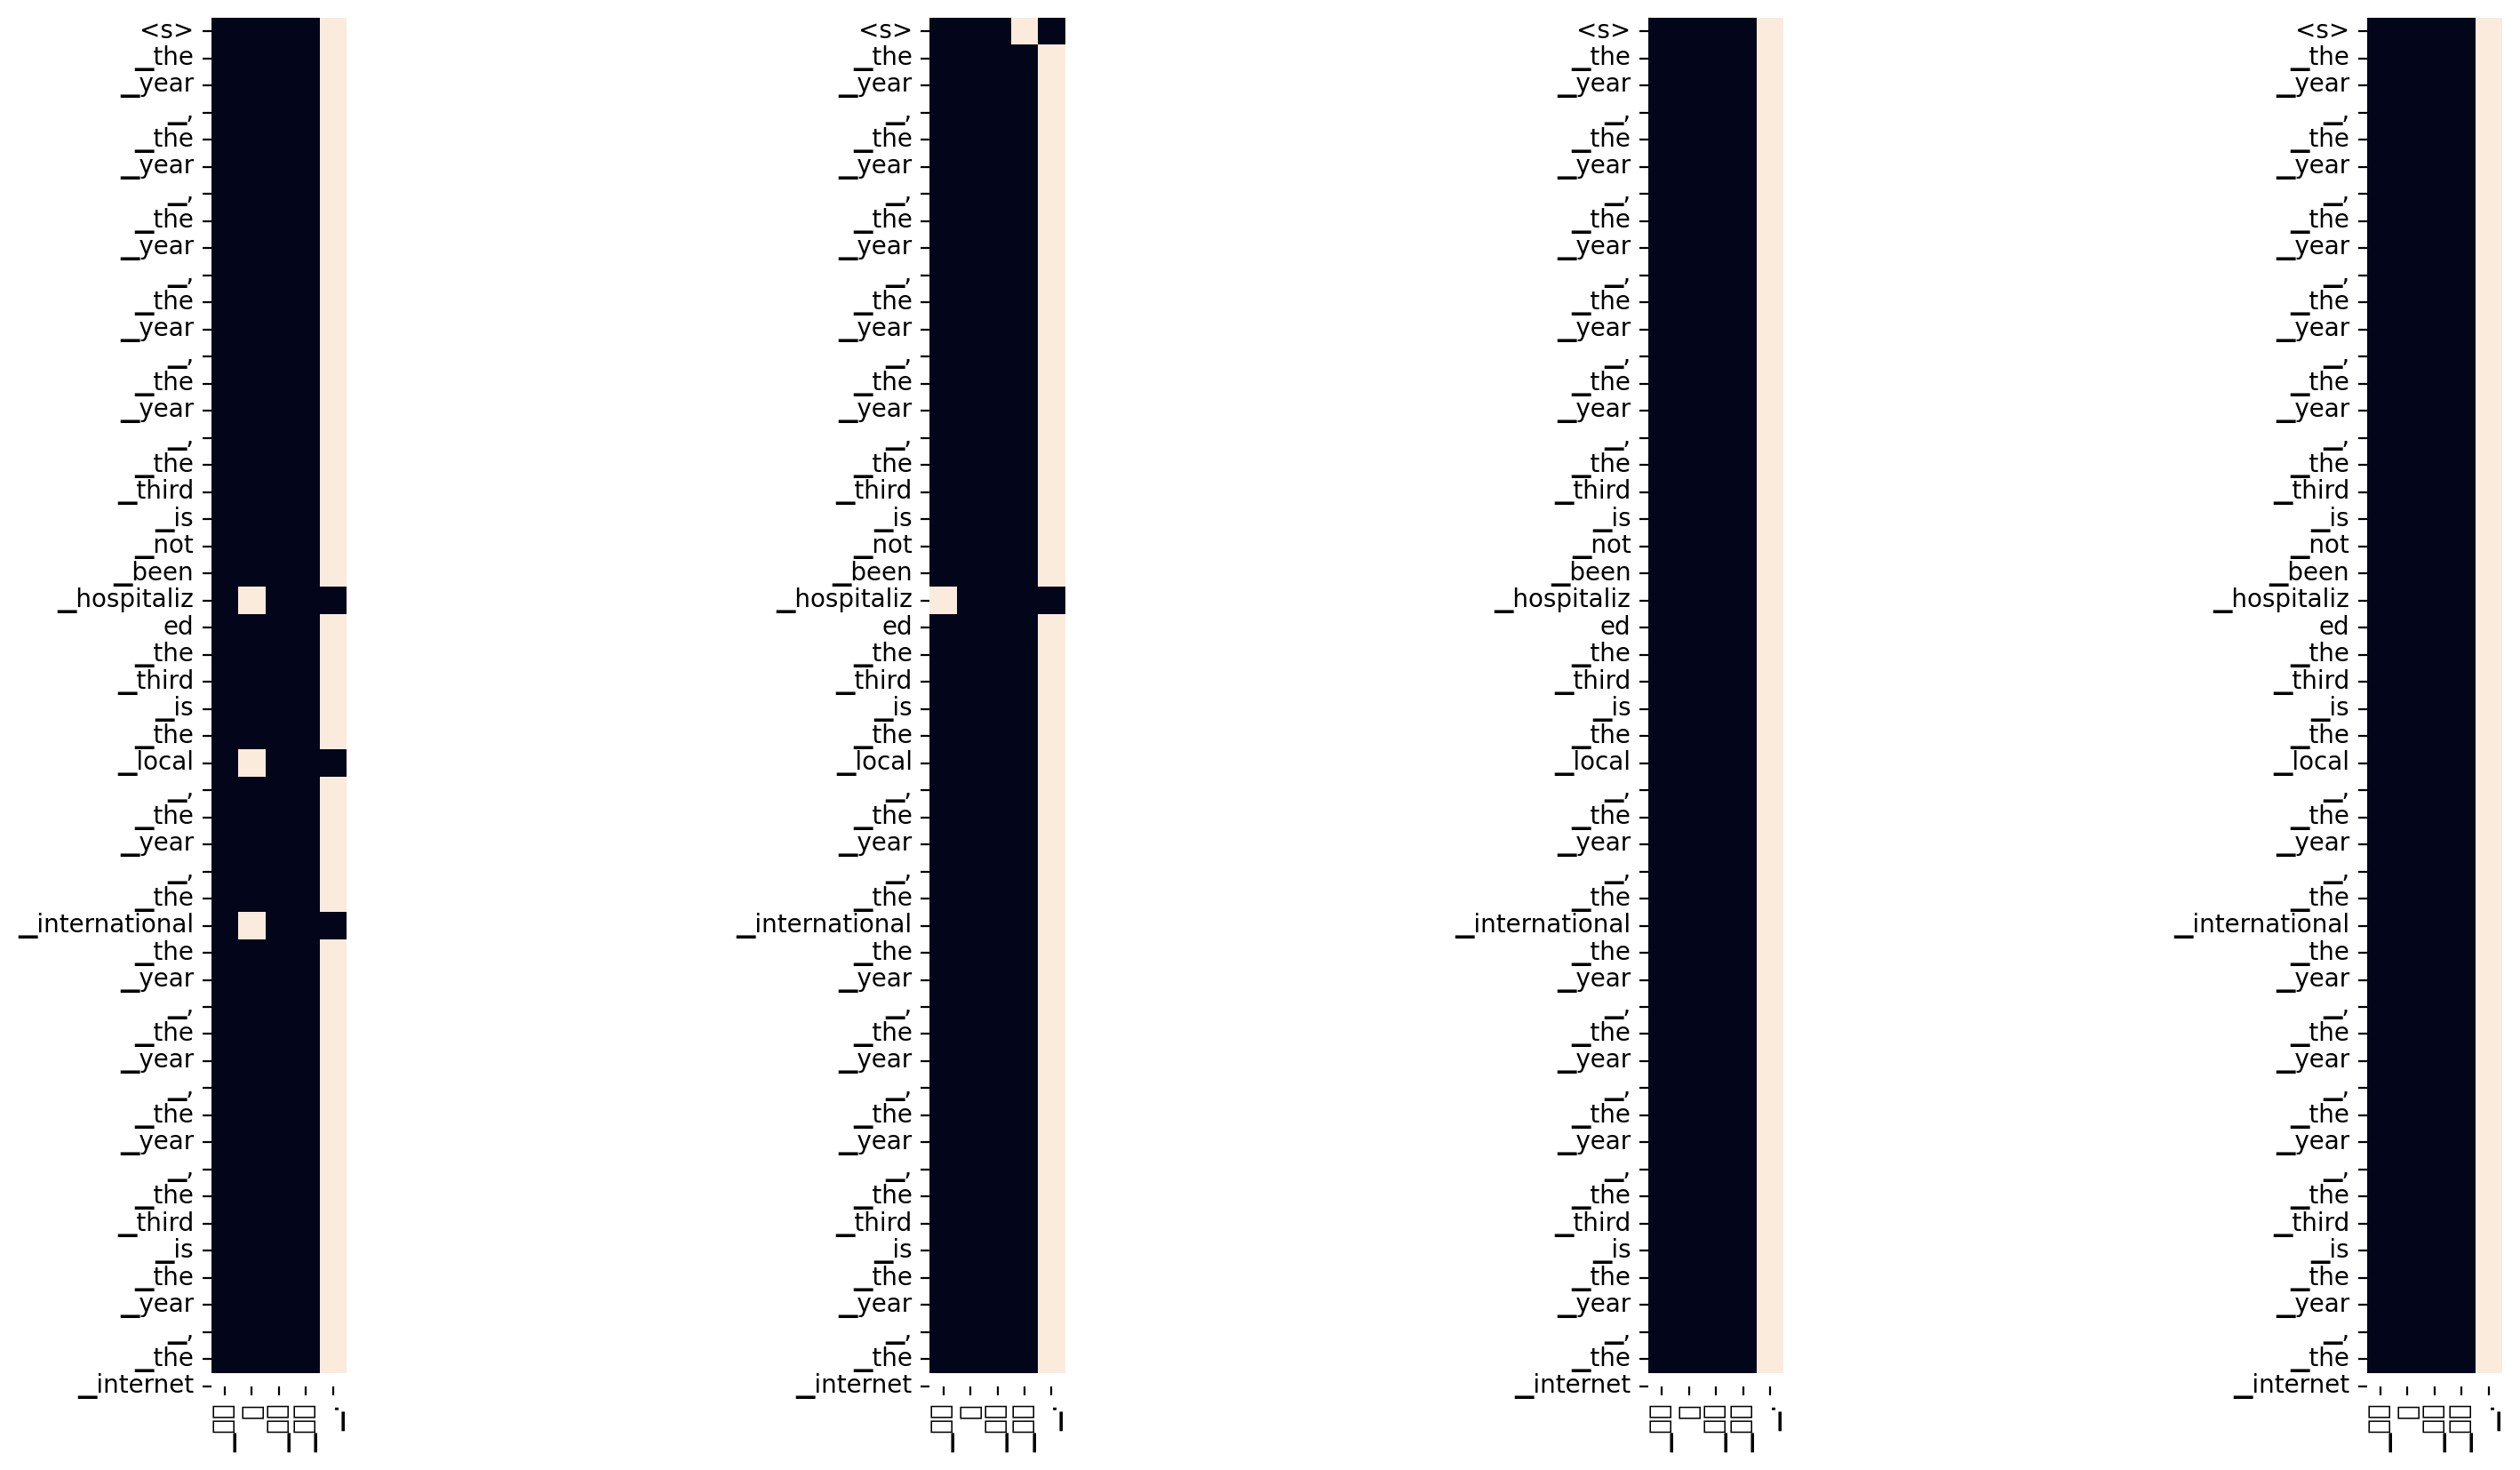

Decoder Self Layer 2


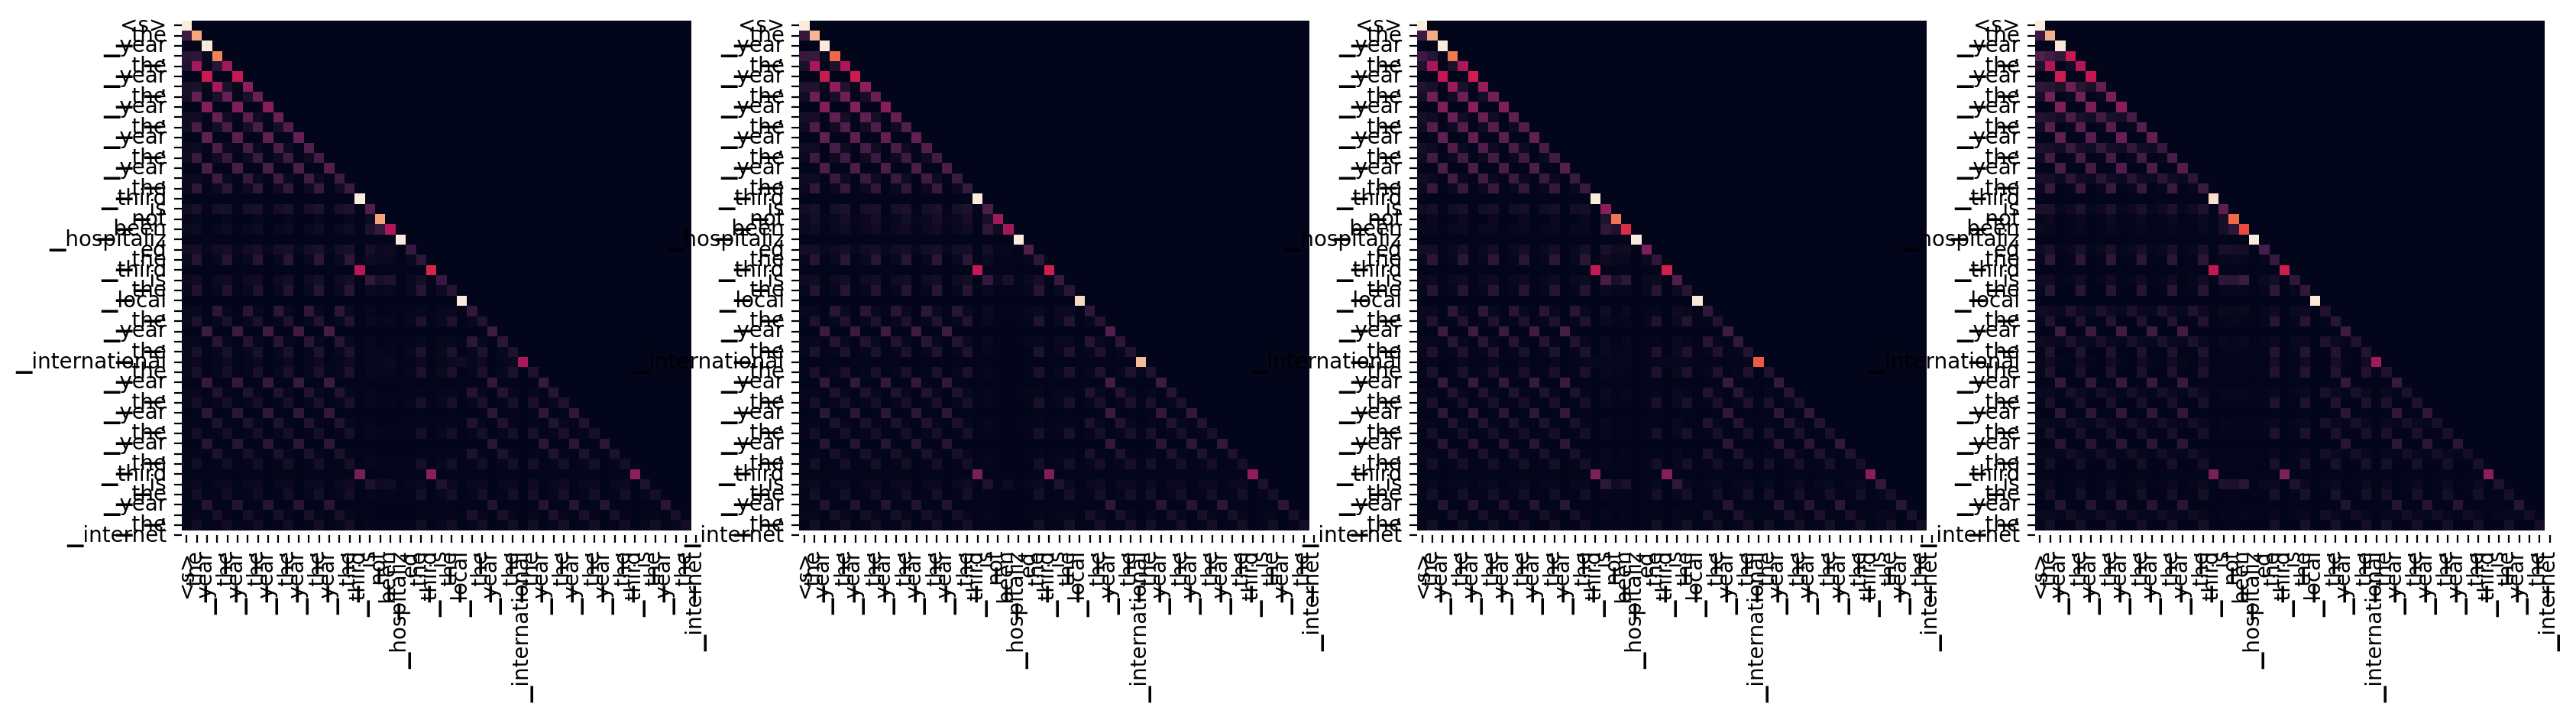

Decoder Src Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

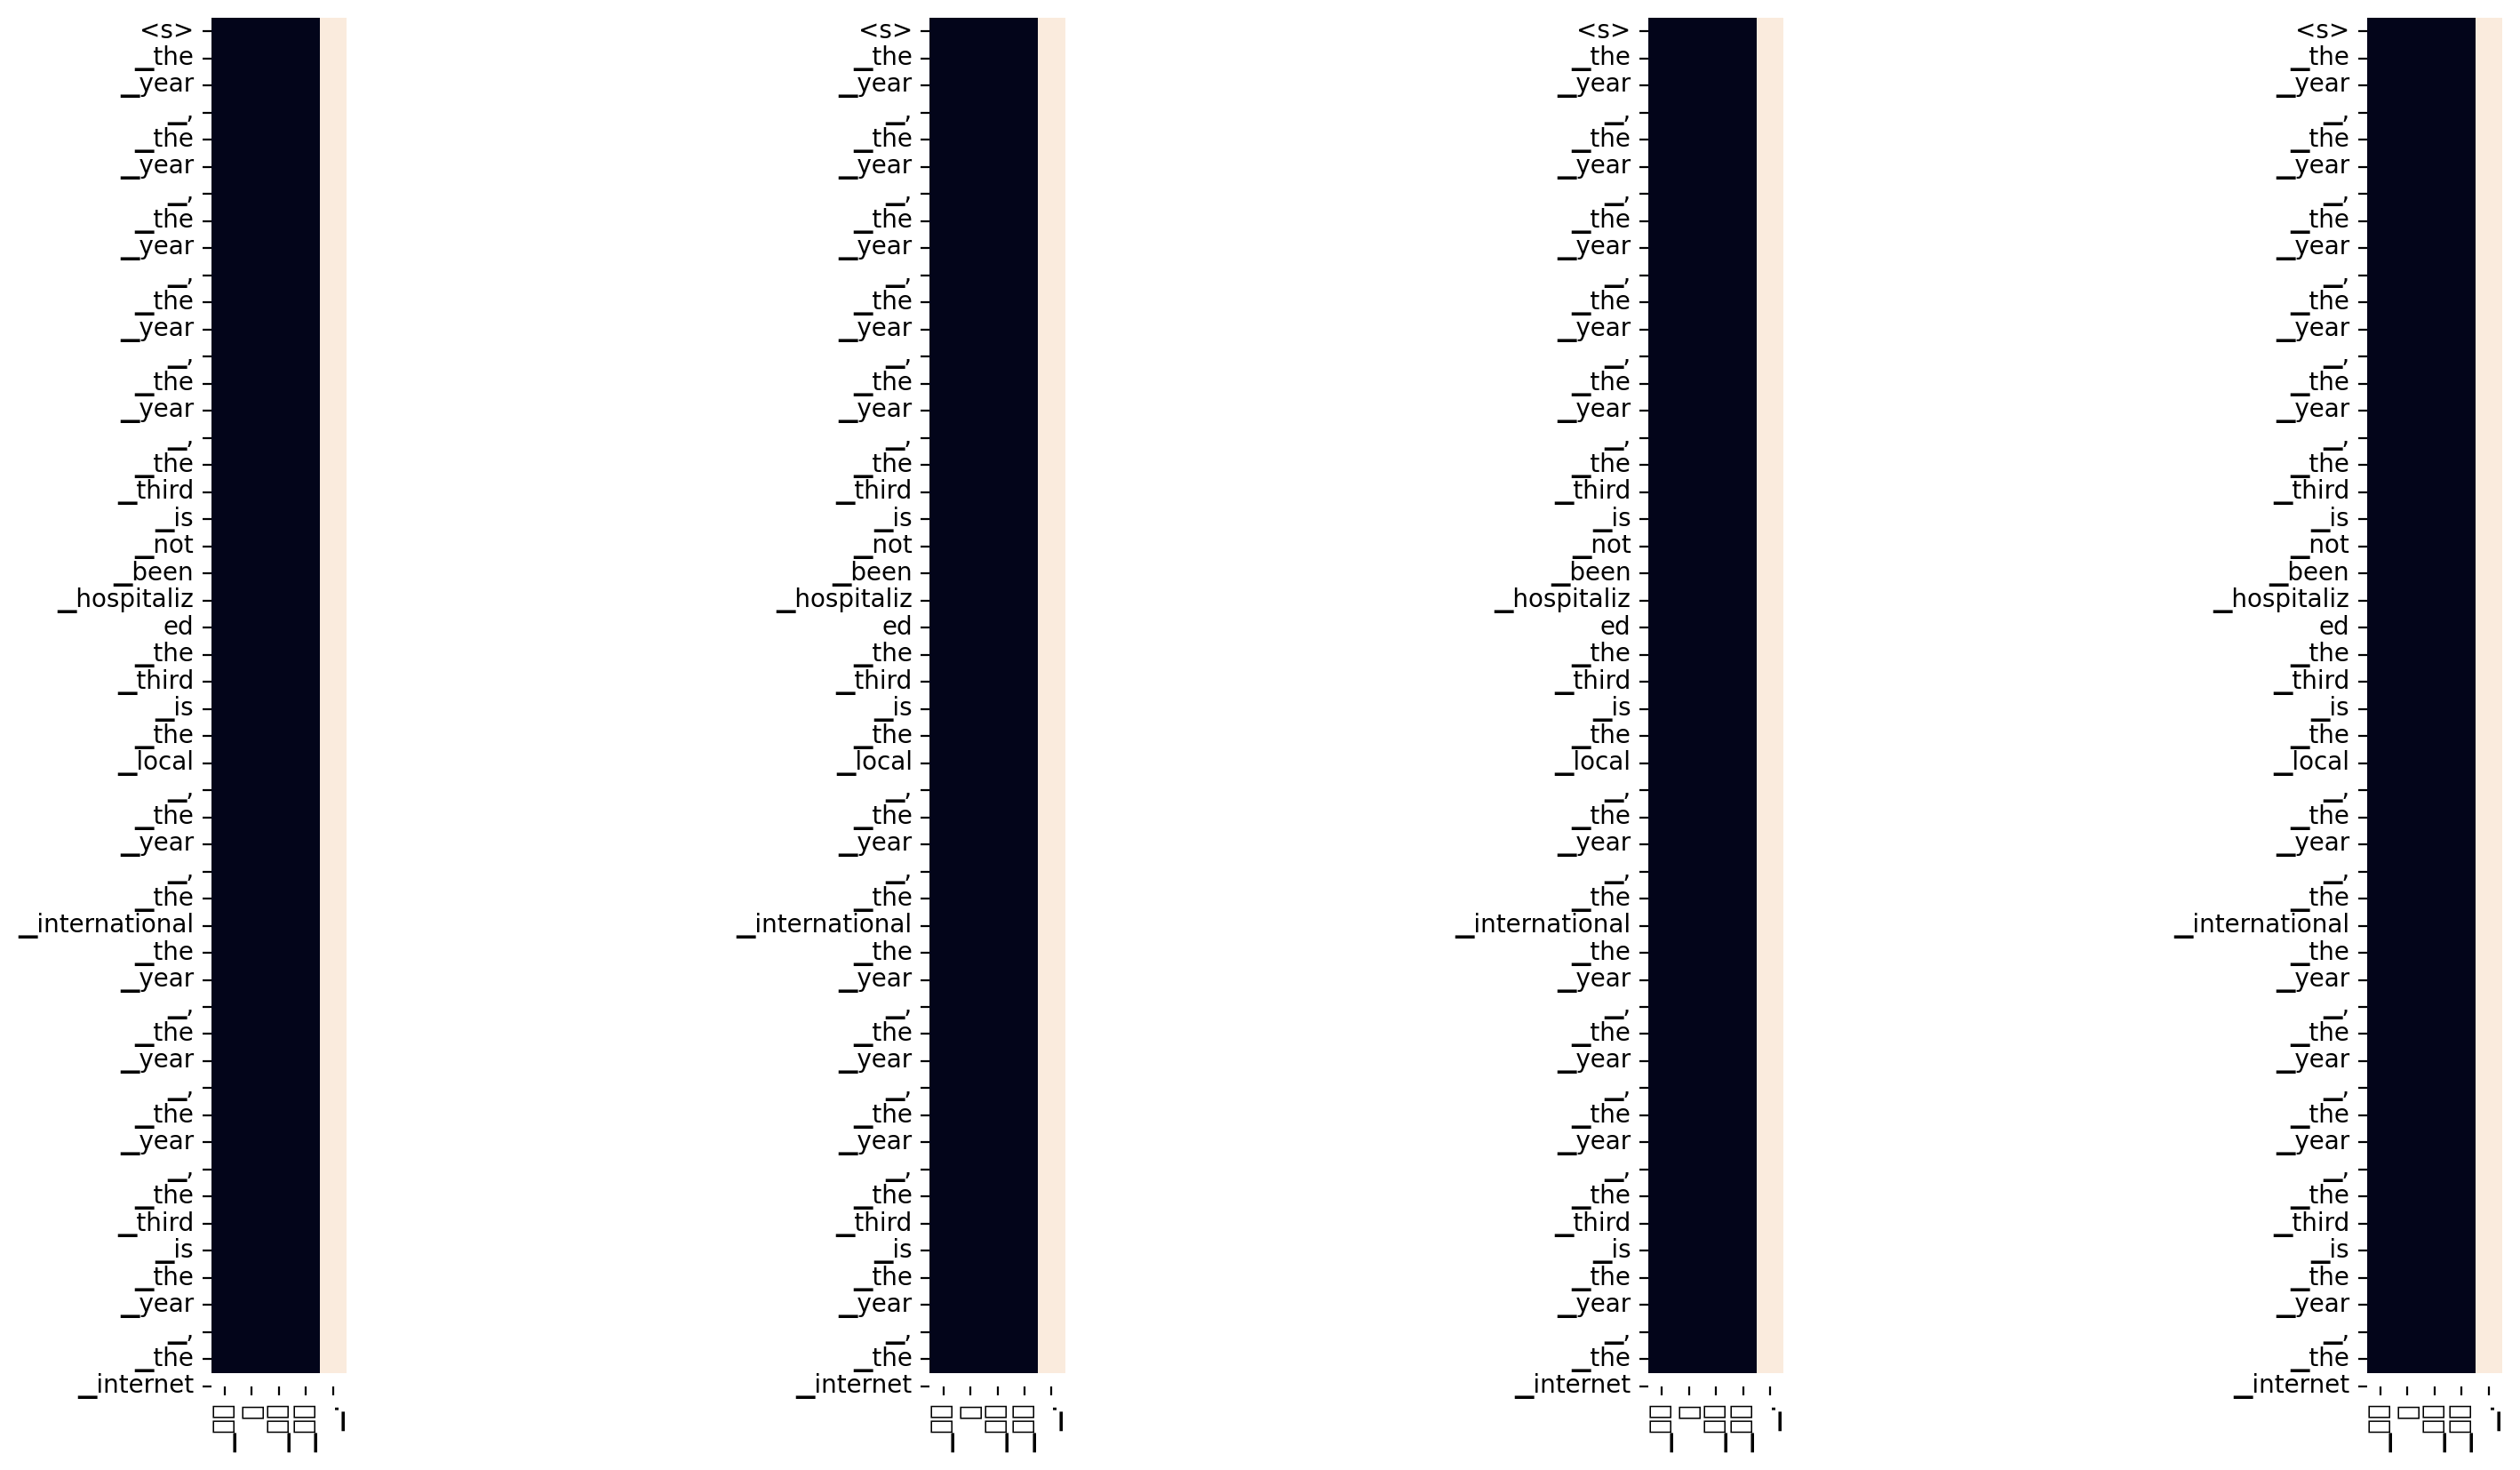


> 예문 4
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the second more than the local the local , the local , the local , the local , the local , the local , the local , the local , the local , the local , the local the local , the local the local , the local , the
Encoder Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

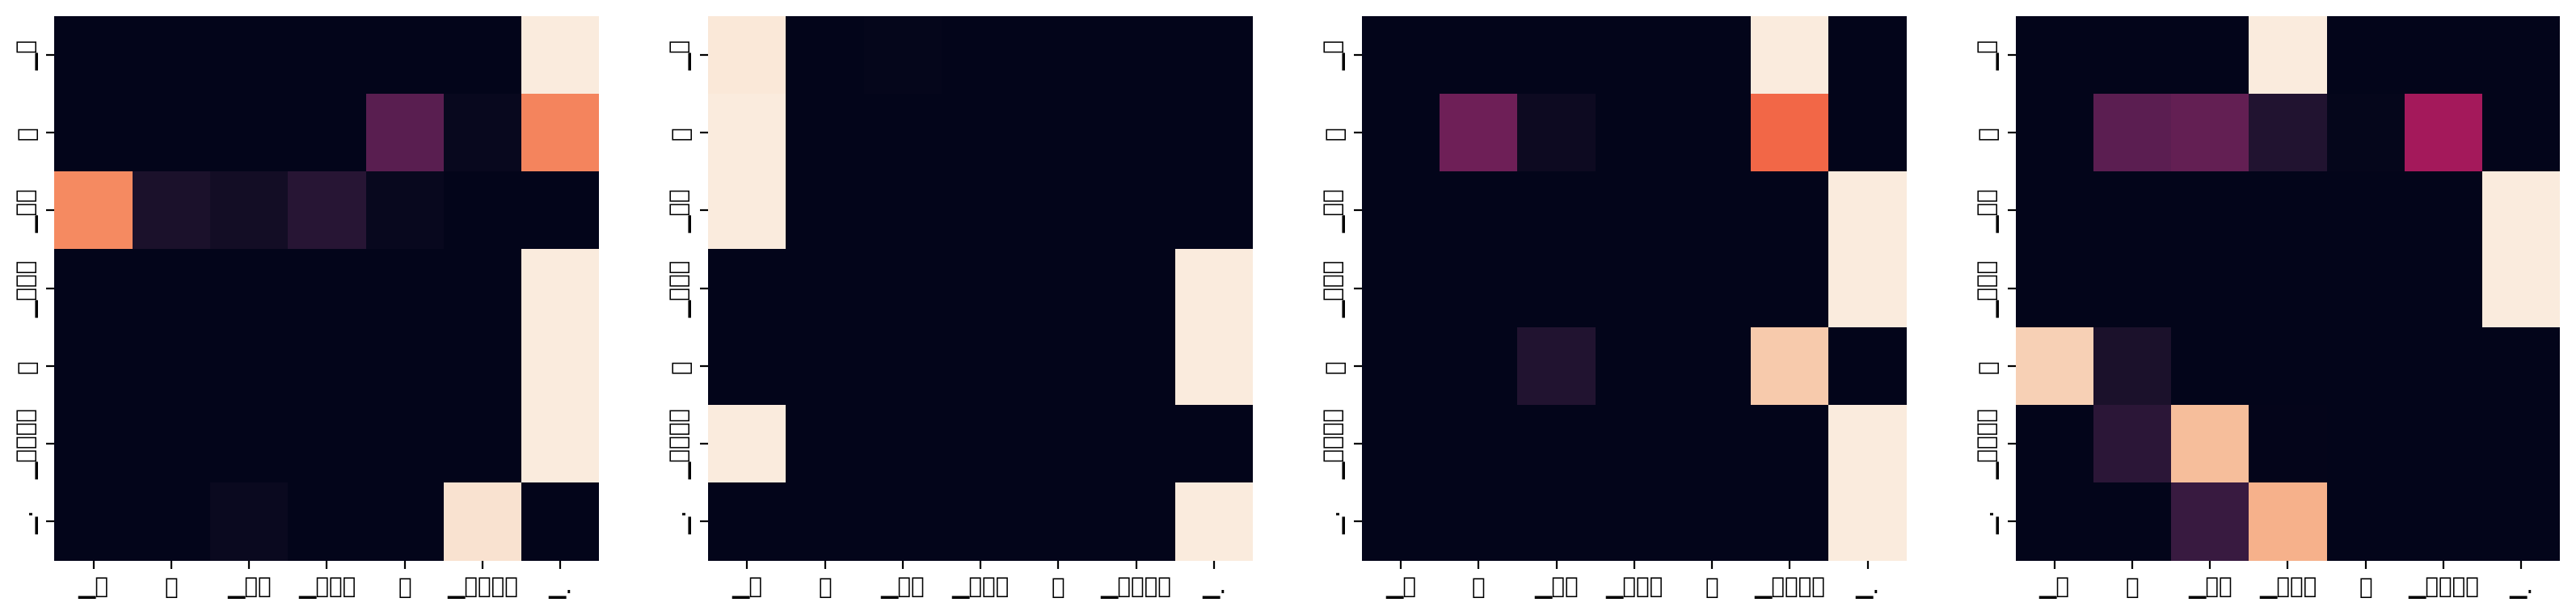

Encoder Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

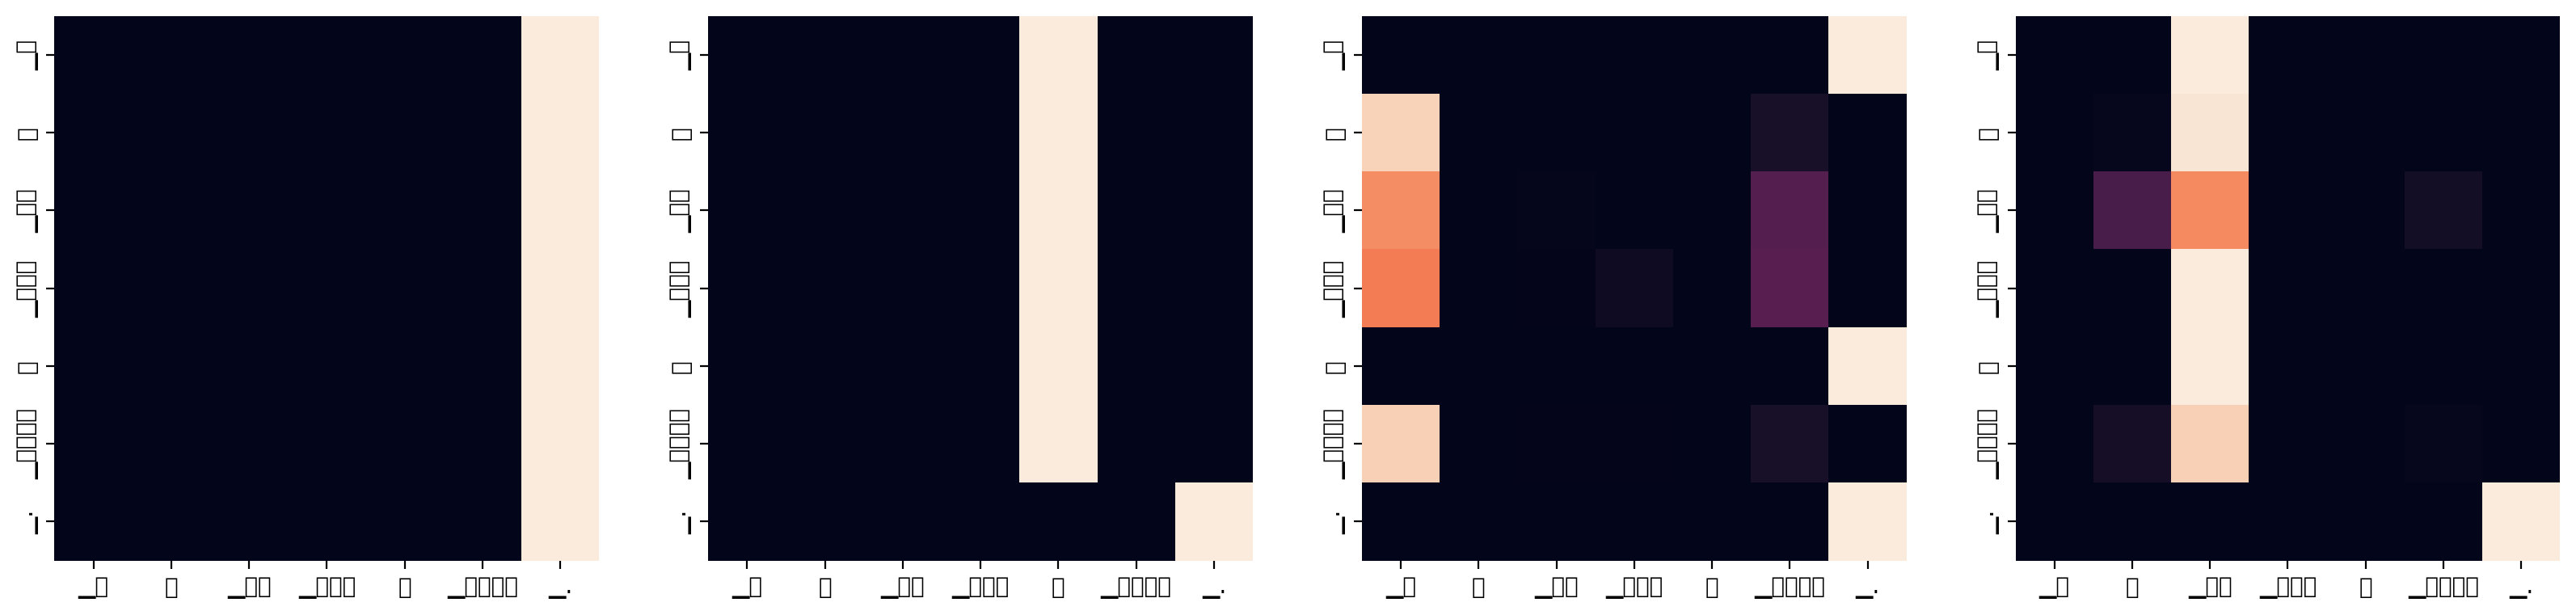

Decoder Self Layer 1


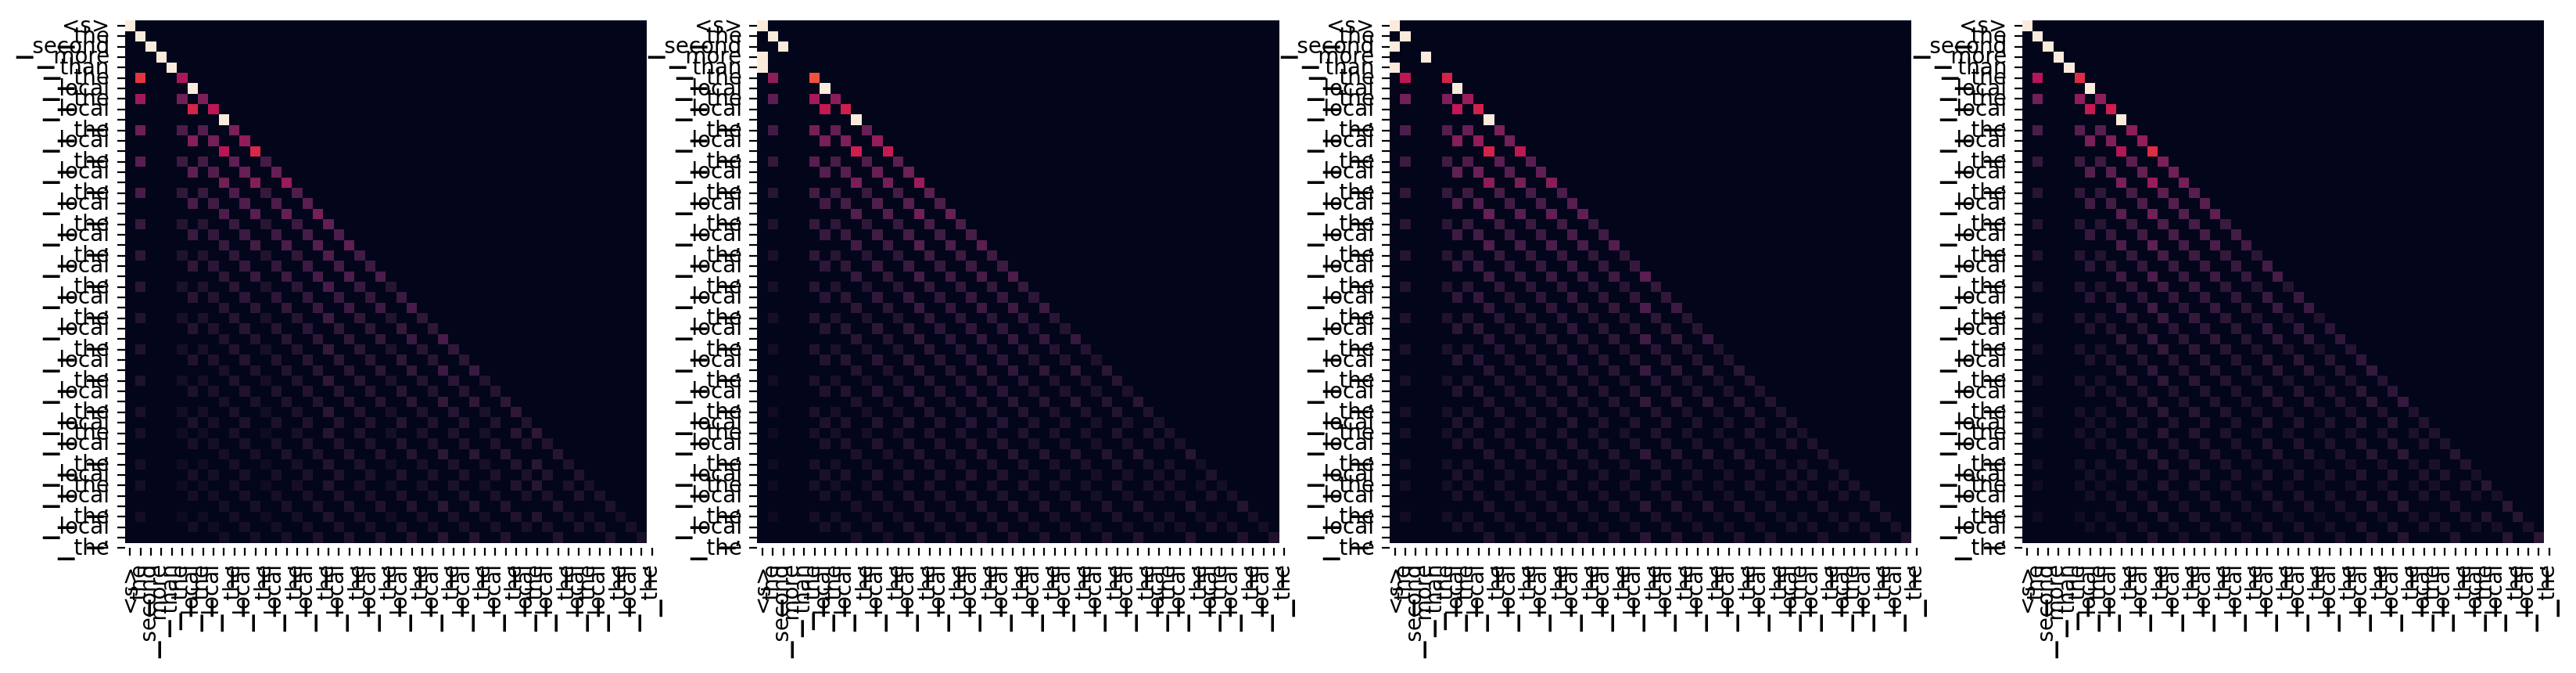

Decoder Src Layer 1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

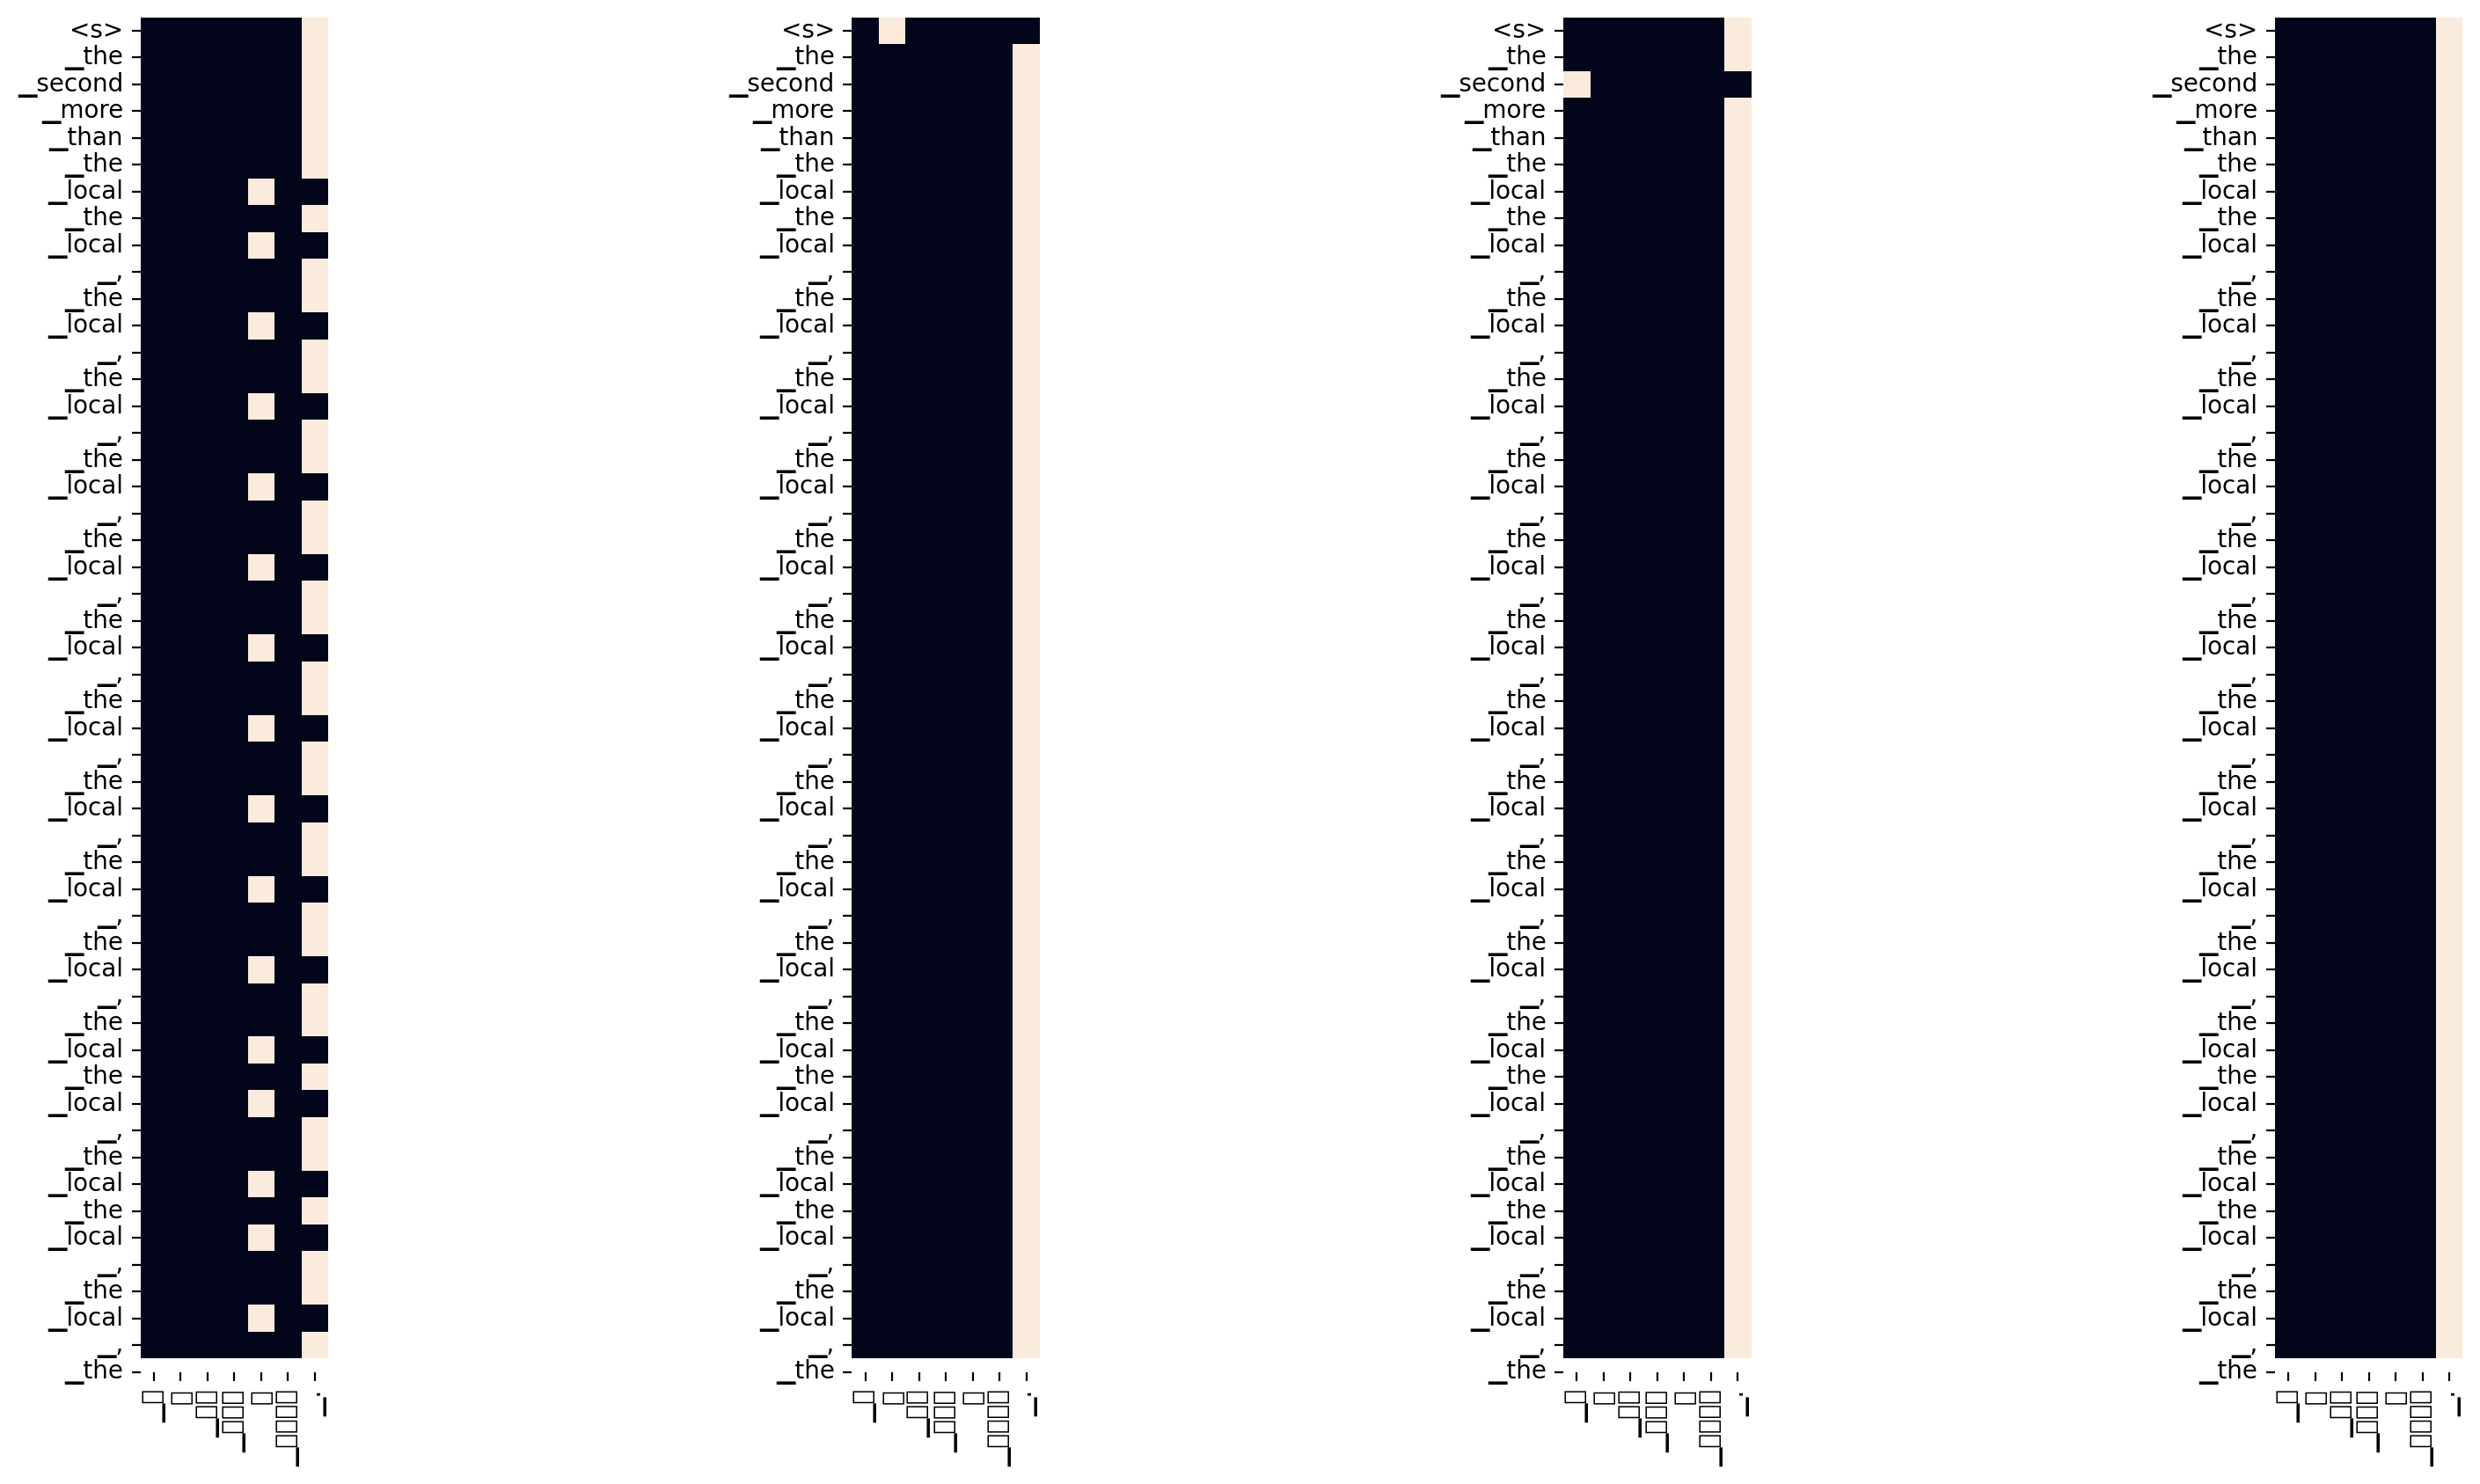

Decoder Self Layer 2


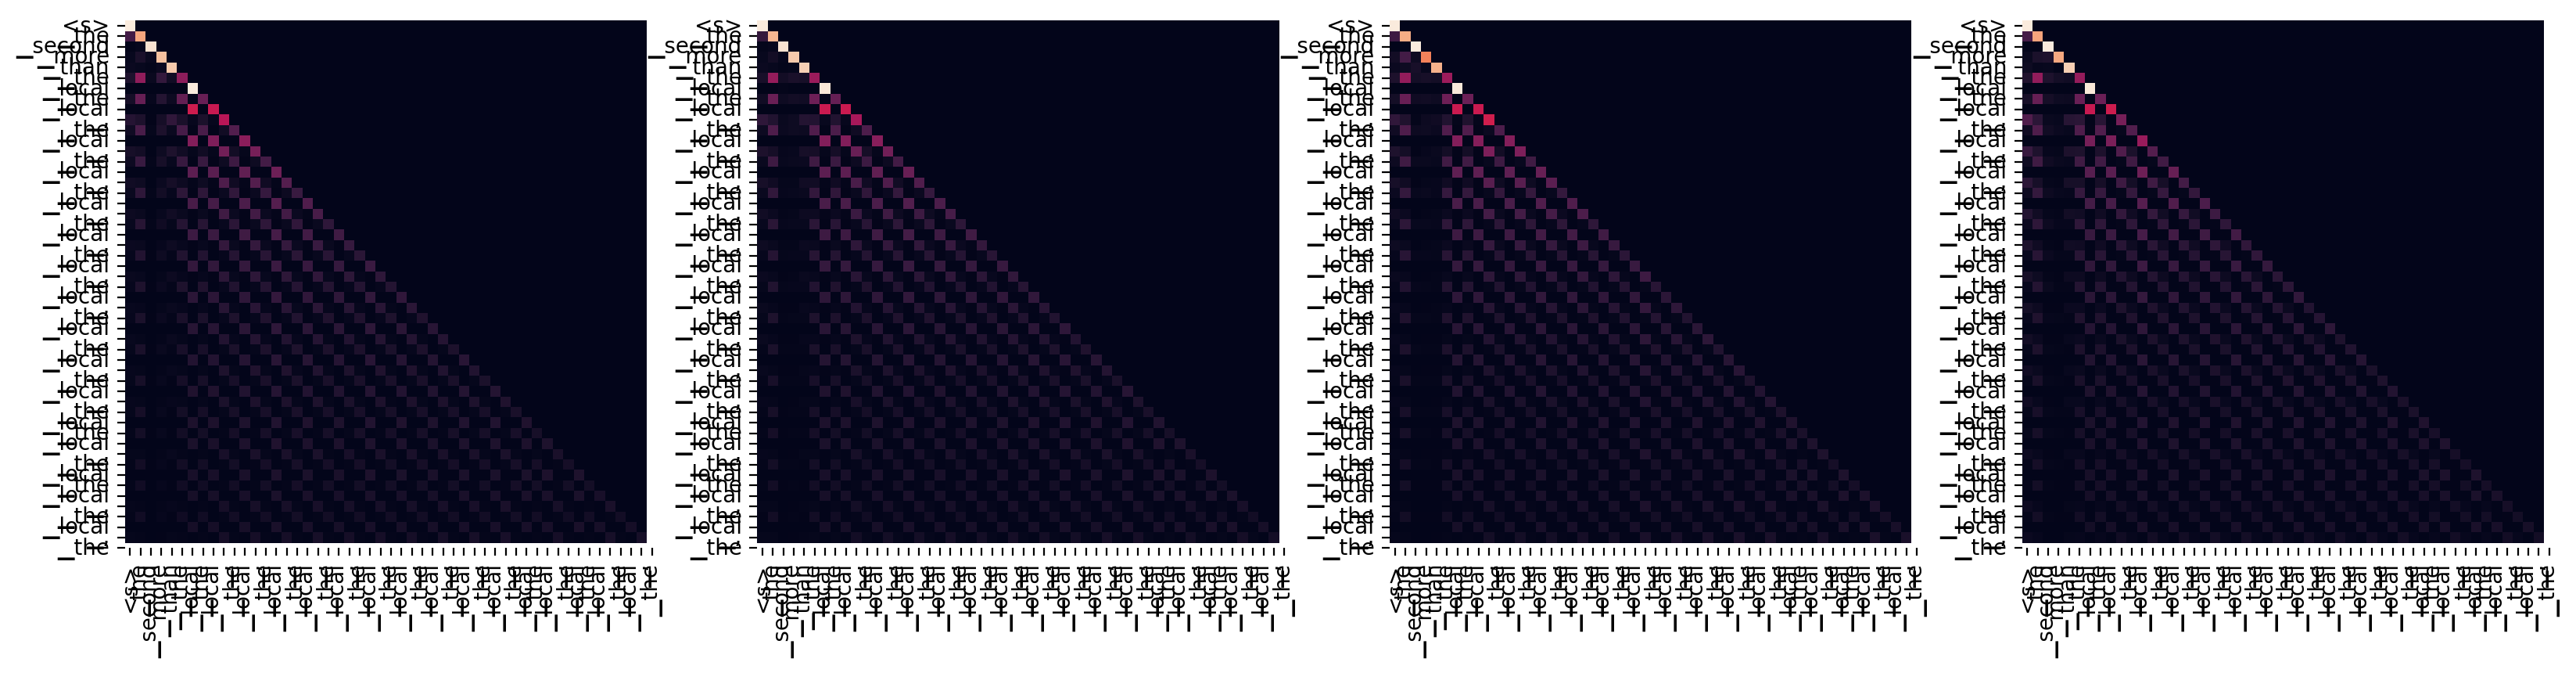

Decoder Src Layer 2


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

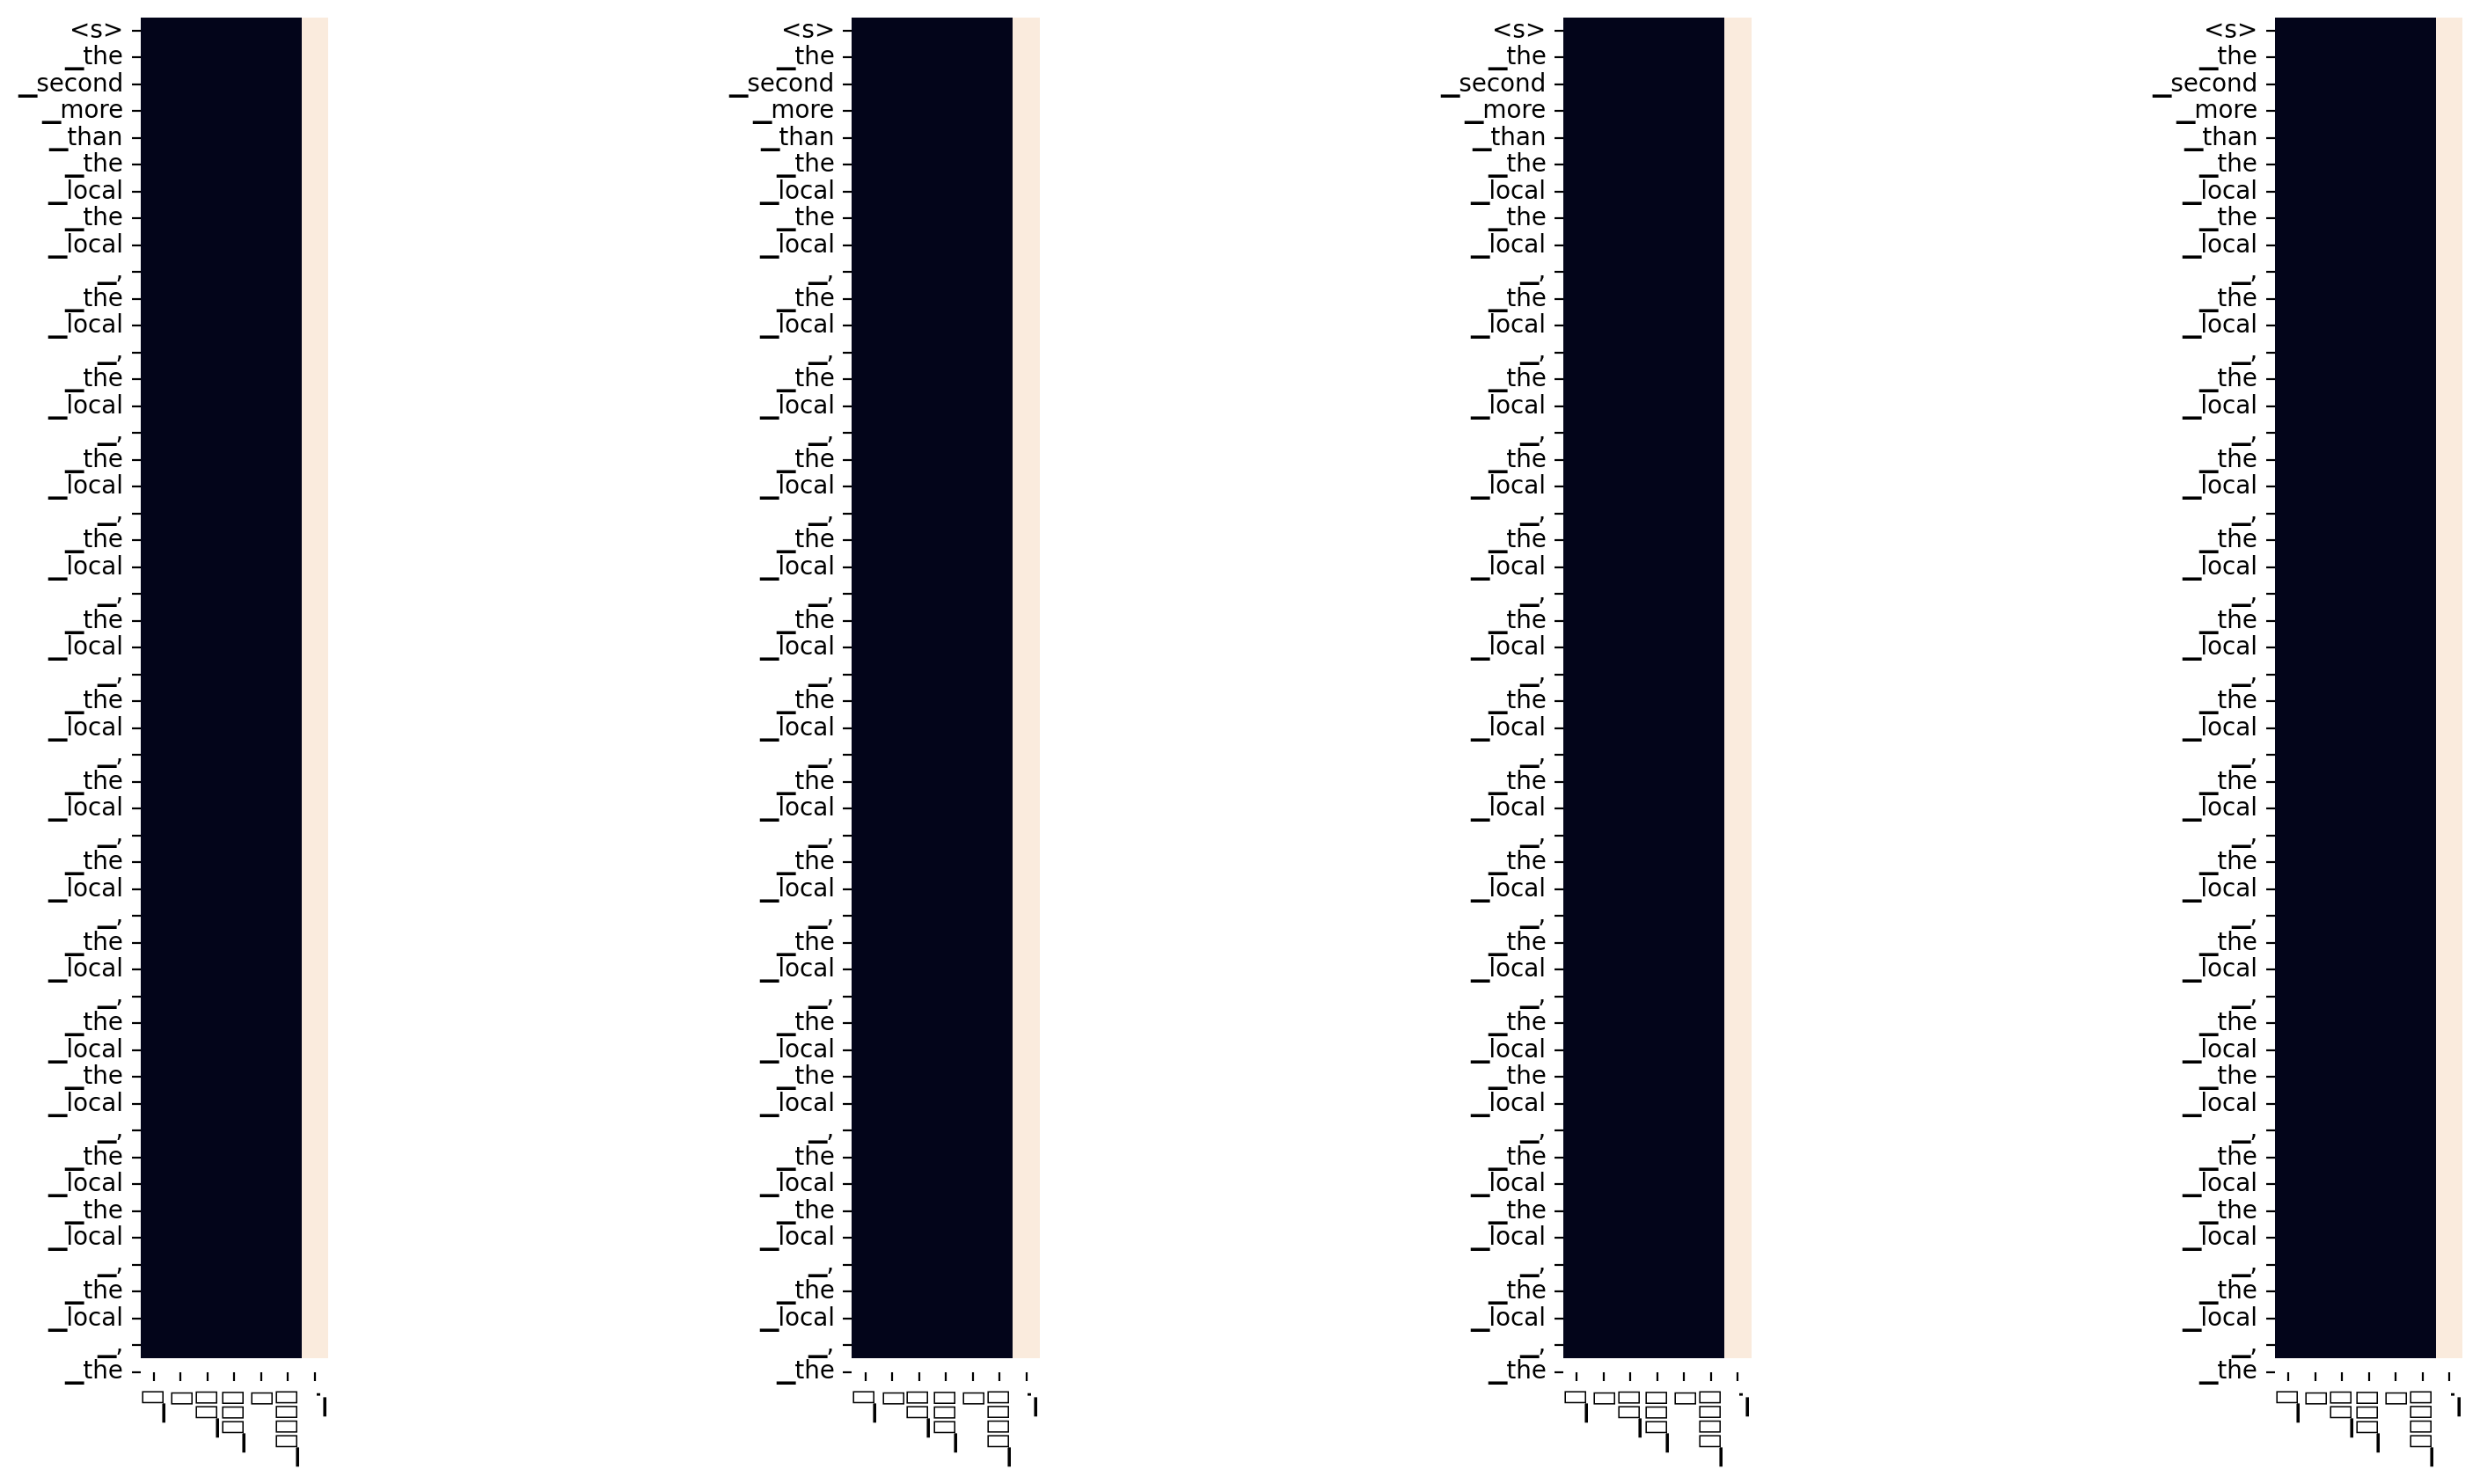

In [26]:
# 최종 번역 결과 + Attention Map 시각화 (평가기준: 시각화된 Attention Map으로 결과 뒷받침)
print("Translations")
for i, example in enumerate(examples):
    print(f"\n> 예문 {i + 1}")
    translate(example, transformer, ko_tokenizer, en_tokenizer, plot_attention=True)


### 회고

- LMS 연결이 되지 않았고, Colab에서 런타임 제한이 걸려서 제약이 많았으나, 수업 종료 전에 10Epoch를 모두 돌려볼 수 있었습니다.